# 2021 Civil Summons Dataset EDA & Cleaning  
- Input: UPDATEDOATH_cleaned_demographic_merge_training_nodates.V2.csv contains: 
  - Tax IDs from raw civil citations
  - Corresponding OATH records based on ticket numbers
  - Disciplinary Action data based on officer tax id 
  - Award data based on offcier tax id
  - Charge data based on officer tax id
  - Arrest data based on officer tax id
  - Allegations data based on officer tax id

Through this notebook, we are looking at the (1) validity of variables, (2) whether to keep or delete variables, (3) standardize/mutate  variables, and (4) add additional/most recent officer variables suitable for an analytical dataset. 

- Output: civil_summons_2021_v1.csv contains:
  - Cleaned OATH variables 
  - Most recent legal aid roster data based on officer tax id
  - Most recent legal aid payrool data based on offcier tax id/officer name 

https://github.com/the-legal-aid-society/LELU/blob/main/README.md 

### Original 2021 Civil Citations EDA

In [3]:
# set up 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import os
os.getcwd()

'/Users/joyamelvin/Desktop/Evidence for Justice Lab/civil-summons-project'

In [5]:
civil_summons_2021 = pd.read_csv("data/UPDATEDOATH_cleaned_demographic_merge_training_nodates.V2.csv")

In [6]:
civil_summons_2021.head()

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,...,total_arrests,final_race,master_dept_recognitions,FS_confirmed_lnamefname,CCDA_casenum,CCDA_disposition,CCDA_charge,AR_award_summary,Completed Training Names,Training Count
0,190851430,PO,Soreca,953430,NYPD,Medium,Medium,.,.,.,...,115.0,WHITE,1.0,"SORECA, NICHOLAS",.,.,.,1 EXCELLENT POLICE DUTY,active bystandership for law enforcement (able...,58.0
1,196184708,.,Ennis,961743,NYPD,High,High,.,.,.,...,63.0,WHITE,0.0,"ENNIS, PATRICIA",.,.,.,.,clt-equal employment opportunity;clt-equal emp...,165.0
2,196241834,.,Wynno,961465,NYPD,Medium,High,.,Winno,.,...,63.0,WHITE,0.0,"WYNNE, JAMES",.,.,.,.,clt-equal employment opportunity;clt-equal emp...,150.0
3,196242292,.,Keniesky,964085,NYPD,Medium,High,.,Kensesky,.,...,35.0,WHITE,0.0,"KENJESKY, MICHAEL",.,.,.,.,arrests - religious head covering guidelines (...,96.0
4,196244840,.,Sinto,964778,NYPD,High,High,.,.,.,...,80.0,WHITE,0.0,"SINTO, MICHAEL",.,.,.,.,active bystandership for law enforcement (able...,94.0


In [7]:
# 2423 unique offers in our civil summons data; we want this number to be assigned to most variables.  
civil_summons_2021.Final_Officer_Tax_ID.nunique()

2423

In [8]:
# 4663 total civil citations matches - the same 
civil_summons_2021.Ticket_Number.count()

4663

In [9]:
civil_summons_2021.columns.tolist()

['Ticket_Number',
 'Complaintants_First_Name',
 'Complaintants_Last_Name',
 'Tax_Registry_Number_Tax_ID',
 'Agency',
 'Confidence_on_PO_Name',
 'Confidence_on_Officer_Tax_ID',
 'Alternative_Officer_First_Name',
 'Alternative_Officer_Last_Name',
 'Alternative_Officer_Tax_ID',
 'Verified_Name_w_Tax_ID',
 'Last_Name_First_Name',
 'If_Partial_Illegible_ID',
 'Final_Officer_First_Name',
 'Final_Officer_Last_Name',
 'Final_Officer_Tax_ID',
 'Computer_Generated_YN',
 'If_Computer_Generated',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_

In [10]:
civil_summons_2021.shape

(4663, 98)

In [11]:
# 2423 unique offers in our civil summons data; we want this number to be assigned to most behavioral variables.  
civil_summons_2021.Final_Officer_Tax_ID.nunique()

2423

In [12]:
civil_summons_2021.Tax_Registry_Number_Tax_ID.describe()

count       4663
unique      2532
top       941927
freq          65
Name: Tax_Registry_Number_Tax_ID, dtype: object

In [13]:
civil_summons_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 98 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ticket_Number                    4663 non-null   int64  
 1   Complaintants_First_Name         4663 non-null   object 
 2   Complaintants_Last_Name          4663 non-null   object 
 3   Tax_Registry_Number_Tax_ID       4663 non-null   object 
 4   Agency                           4663 non-null   object 
 5   Confidence_on_PO_Name            4663 non-null   object 
 6   Confidence_on_Officer_Tax_ID     4663 non-null   object 
 7   Alternative_Officer_First_Name   4663 non-null   object 
 8   Alternative_Officer_Last_Name    4663 non-null   object 
 9   Alternative_Officer_Tax_ID       4663 non-null   object 
 10  Verified_Name_w_Tax_ID           4663 non-null   object 
 11  Last_Name_First_Name             4663 non-null   object 
 12  If_Partial_Illegible

In [14]:
# Quick turn these columns from object into int64 

cols = [
    'Final_Officer_Tax_ID',
    'O_Add_Penalties_Late_Fees',
    'aa_felony_arrest_count',
    'aa_infraction_arrest_count',
    'aa_misdemeanor_arrest_count',
    'aa_other_arrest_count',
    'aa_violation_arrest_count'
]

for col in cols:
    civil_summons_2021[col] = (
        pd.to_numeric(civil_summons_2021[col], errors='coerce')
          .fillna(0)
          .astype('int64')
    )

In [15]:
civil_summons_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 98 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Ticket_Number                    4663 non-null   int64 
 1   Complaintants_First_Name         4663 non-null   object
 2   Complaintants_Last_Name          4663 non-null   object
 3   Tax_Registry_Number_Tax_ID       4663 non-null   object
 4   Agency                           4663 non-null   object
 5   Confidence_on_PO_Name            4663 non-null   object
 6   Confidence_on_Officer_Tax_ID     4663 non-null   object
 7   Alternative_Officer_First_Name   4663 non-null   object
 8   Alternative_Officer_Last_Name    4663 non-null   object
 9   Alternative_Officer_Tax_ID       4663 non-null   object
 10  Verified_Name_w_Tax_ID           4663 non-null   object
 11  Last_Name_First_Name             4663 non-null   object
 12  If_Partial_Illegible_ID          4

In [16]:
civil_summons_2021.master_command.head()

0    046 PRECINCT
1    070 PRECINCT
2    101 PRECINCT
3    101 PRECINCT
4    101 PRECINCT
Name: master_command, dtype: object

### 2021 OATH EDA 
The OATH Hearings Division Case Status dataset contains information about alleged public safety and quality of life violations that are filed and adjudicated through the City’s administrative law court, the NYC Office of Administrative Trials and Hearings (OATH) and provides information about the infraction charged, decision outcome, payments, amounts and fees relating to the each civil summons ticket. This data was merged via ticket_number.


#### O_Violation_Date : The date on which the alleged violation indicated on the summons occurred
ANALYSIS: Make categorical; More citations given during the colder months

In [19]:
civil_summons_2021['O_Violation_Date'].head()

0    2/25/21
1    1/15/21
2     1/4/21
3     3/2/21
4     1/1/21
Name: O_Violation_Date, dtype: object

In [20]:
# O_Violation_Date : The date on which the alleged violation indicated on the summons occurred
# IMPORTANT: More citations given during the colder months

civil_summons_2021['O_Violation_Date'] = pd.to_datetime(
    civil_summons_2021['O_Violation_Date'],
    format='%m/%d/%y',
    errors="coerce"
)

In [21]:
# Making sure my dates are counted correctly; sconsistent 14 tickets without information 
civil_summons_2021['O_Violation_Date'].head(10)
civil_summons_2021['O_Violation_Date'].isna().sum()

14

In [22]:
civil_summons_2021[civil_summons_2021.isna().any(axis=1)]

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,...,total_arrests,final_race,master_dept_recognitions,FS_confirmed_lnamefname,CCDA_casenum,CCDA_disposition,CCDA_charge,AR_award_summary,Completed Training Names,Training Count
663,202985860,.,Apolinaro,932265,NYPD,High,High,.,.,.,...,206.0,HISPANIC,0.0,"APOLINARIO, OSCAR",.,.,.,.,clt-crime control strategies and problem solvi...,97.0
811,209565795,.,Daquet,950273,NYPD,High,Medium,.,.,.,...,65.0,WHITE,0.0,"DAQUET, JOHNNIE",.,.,.,.,clt-crime control strategies and problem solvi...,63.0
1827,204592080,Michael,Relf,947390,NYPD,High,High,.,.,.,...,400.0,WHITE,4.0,"RELF, MICHAEL",.,.,.,4 EXCELLENT POLICE DUTY,clt-community engagement;clt-equal employment ...,66.0
2045,198058291,.,Abdalla,948580,NYPD,High,High,.,.,.,...,292.0,BLACK,4.0,"ABDALLA, AHMED",". / ['2014-11400', '2014-11400', '2017-18317']",". / ['GUILTY', 'GUILTY', 'GUILTY']",". / [""WHILE ON-DUTY, ABUSED HIS AUTHORITY WHEN...",4 EXCELLENT POLICE DUTY,clt-equal employment opportunity;clt-procedura...,70.0
2182,201446897,.,Roman,.,NYPD,High,Low,.,.,.,...,230.0,HISPANIC,11.0,"ROMAN, DANIEL",.,.,.,7 EXCELLENT POLICE DUTY / 4 MERITORIOUS POLICE...,.,.
2549,206212041,.,Martinez,953056,NYPD,High,High,.,.,.,...,85.0,HISPANIC,3.0,"MARTINEZ, ALEXIS",.,.,.,3 EXCELLENT POLICE DUTY,active bystandership for law enforcement (able...,33.0
3112,206215240,.,Rivera,955380,NYPD,High,Medium,.,.,953380,...,141.0,HISPANIC,5.0,"RIVERA, DEAN",.,.,.,4 EXCELLENT POLICE DUTY / 1 MERITORIOUS POLICE...,arrests - religious head covering guidelines (...,46.0
3245,214587726,.,Arrigo,968948,NYPD,High,Medium,.,.,968946,...,3.0,WHITE,0.0,"ARRIGO, KAYLIN",.,.,.,.,active bystandership for law enforcement (able...,40.0
3659,208116160,.,Novak,962641,NYPD,High,High,.,.,.,...,38.0,WHITE,0.0,"NOVAK, CHARLES",.,.,.,.,clt-procedural operations;investigative encoun...,59.0
3662,211803965,.,Crooks,960824,NYPD,High,High,.,.,.,...,61.0,BLACK,1.0,"CROOKS, BRIAN",.,.,.,1 EXCELLENT POLICE DUTY,clt-equal employment opportunity;clt-procedura...,61.0


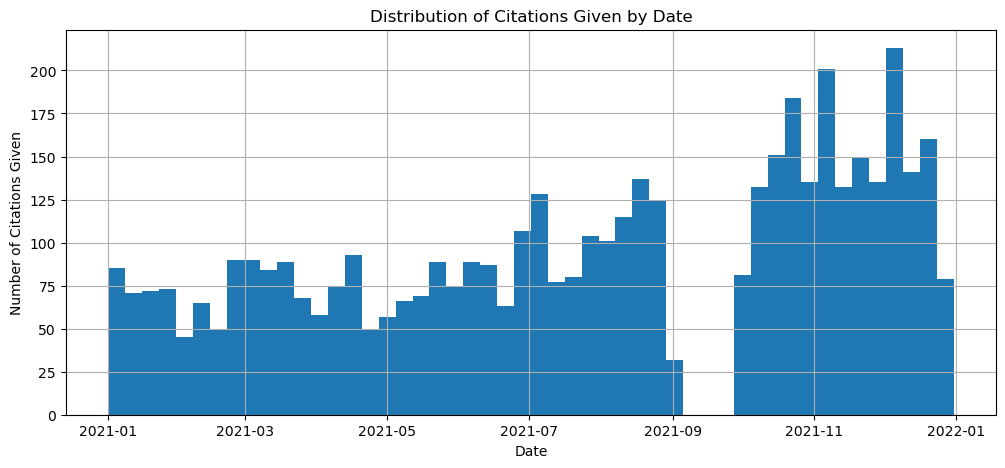

In [23]:
# Distribution of dates 
civil_summons_2021['O_Violation_Date'].hist(figsize=(12,5), bins=50)
plt.title("Distribution of Citations Given by Date")
plt.xlabel("Date")
plt.ylabel("Number of Citations Given")

plt.savefig('EDA_figures/Citations_Given_by_Date.png', dpi=300, bbox_inches='tight')
plt.show()

#### O_Violation_Date --> month_issued 
- Creating numerical variable from violation date for each month ticket was issued
  

In [25]:
civil_summons_2021['O_Violation_Date'].value_counts()

O_Violation_Date
2021-11-29    46
2021-11-05    43
2021-12-05    41
2021-12-23    37
2021-10-22    37
              ..
2021-02-07     3
2021-02-19     3
2021-01-31     3
2021-12-25     2
2021-02-02     2
Name: count, Length: 332, dtype: int64

In [26]:
civil_summons_2021['month_issued'] = pd.to_datetime(civil_summons_2021['O_Violation_Date']).dt.month

In [27]:
civil_summons_2021['month_issued'].value_counts()

month_issued
10.0    649
11.0    636
12.0    608
8.0     509
7.0     403
6.0     365
3.0     348
1.0     304
5.0     303
4.0     277
2.0     247
Name: count, dtype: int64

#### O_Violation_Time : The time of day at which the alleged violation indicated on the summons occurred
ANALYSIS: More citations in the evening and the afternoon, in comparison to the morning, night, and early morning. 

In [29]:
civil_summons_2021['O_Violation_Time'].head(10)

0    12:48:00
1    18:35:00
2    17:20:00
3     9:48:00
4    21:40:00
5    17:20:00
6    19:55:00
7    22:00:00
8    19:05:00
9    21:15:00
Name: O_Violation_Time, dtype: object

In [30]:
# O_Violation_Time : The time of day at which the alleged violation indicated on the summons occurred
# IMPORTANT: 
civil_summons_2021['Violation_Hour'] = pd.to_datetime(
    civil_summons_2021['O_Violation_Time'],
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

# Making sure my dates are counted correctly
civil_summons_2021['Violation_Hour'].head(10)
civil_summons_2021['Violation_Hour'].isna().sum()


14

In [31]:
civil_summons_2021[civil_summons_2021['Violation_Hour'].isna()]


,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,...,master_dept_recognitions,FS_confirmed_lnamefname,CCDA_casenum,CCDA_disposition,CCDA_charge,AR_award_summary,Completed Training Names,Training Count,month_issued,Violation_Hour
663,202985860,.,Apolinaro,932265,NYPD,High,High,.,.,.,...,0.0,"APOLINARIO, OSCAR",.,.,.,.,clt-crime control strategies and problem solvi...,97.0,NaN,NaN
811,209565795,.,Daquet,950273,NYPD,High,Medium,.,.,.,...,0.0,"DAQUET, JOHNNIE",.,.,.,.,clt-crime control strategies and problem solvi...,63.0,NaN,NaN
1827,204592080,Michael,Relf,947390,NYPD,High,High,.,.,.,...,4.0,"RELF, MICHAEL",.,.,.,4 EXCELLENT POLICE DUTY,clt-community engagement;clt-equal employment ...,66.0,NaN,NaN
2045,198058291,.,Abdalla,948580,NYPD,High,High,.,.,.,...,4.0,"ABDALLA, AHMED",". / ['2014-11400', '2014-11400', '2017-18317']",". / ['GUILTY', 'GUILTY', 'GUILTY']",". / [""WHILE ON-DUTY, ABUSED HIS AUTHORITY WHEN...",4 EXCELLENT POLICE DUTY,clt-equal employment opportunity;clt-procedura...,70.0,NaN,NaN
2182,201446897,.,Roman,.,NYPD,High,Low,.,.,.,...,11.0,"ROMAN, DANIEL",.,.,.,7 EXCELLENT POLICE DUTY / 4 MERITORIOUS POLICE...,.,.,NaN,NaN
2549,206212041,.,Martinez,953056,NYPD,High,High,.,.,.,...,3.0,"MARTINEZ, ALEXIS",.,.,.,3 EXCELLENT POLICE DUTY,active bystandership for law enforcement (able...,33.0,NaN,NaN
3112,206215240,.,Rivera,955380,NYPD,High,Medium,.,.,953380,...,5.0,"RIVERA, DEAN",.,.,.,4 EXCELLENT POLICE DUTY / 1 MERITORIOUS POLICE...,arrests - religious head covering guidelines (...,46.0,NaN,NaN
3245,214587726,.,Arrigo,968948,NYPD,High,Medium,.,.,968946,...,0.0,"ARRIGO, KAYLIN",.,.,.,.,active bystandership for law enforcement (able...,40.0,NaN,NaN
3659,208116160,.,Novak,962641,NYPD,High,High,.,.,.,...,0.0,"NOVAK, CHARLES",.,.,.,.,clt-procedural operations;investigative encoun...,59.0,NaN,NaN
3662,211803965,.,Crooks,960824,NYPD,High,High,.,.,.,...,1.0,"CROOKS, BRIAN",.,.,.,1 EXCELLENT POLICE DUTY,clt-equal employment opportunity;clt-procedura...,61.0,NaN,NaN


In [32]:
# Binning time by early morning (00-05); Morning (06-11); Afternoon (12-16); Evening (12-20); Night (21-23) 

# Function for binning hours 
def time_of_day(hour):
    if pd.isna(hour):
        return None
    if 0 <= hour < 6:
        return "Early Morning"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

civil_summons_2021['O_Violation_Time_Category'] = civil_summons_2021['Violation_Hour'].apply(time_of_day)

In [33]:
civil_summons_2021['O_Violation_Time_Category'].value_counts()


O_Violation_Time_Category
Evening          1509
Afternoon        1420
Morning           905
Night             496
Early Morning     319
Name: count, dtype: int64

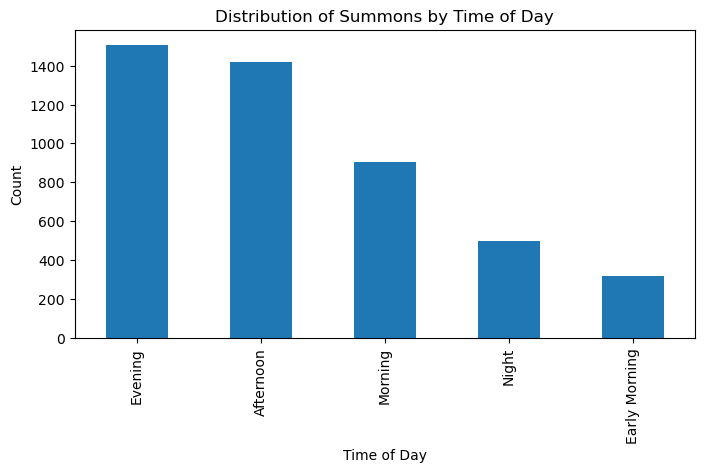

In [34]:
civil_summons_2021['O_Violation_Time_Category'].value_counts().plot(
    kind='bar',
    figsize=(8,4),
    title='Distribution of Summons by Time of Day'
)
plt.xlabel('Time of Day')
plt.ylabel('Count')

plt.savefig('EDA_figures/Distribution of Summons by Time of Day.png', dpi=300, bbox_inches='tight')
plt.show()


#### O_Balance_Due: The balance of the monetary penalty owed by the respondent
**DELETE**


ANALYSIS: Average balance due is around $16; matches literature that most citations result in no penalty fine, if the burden is resolved (which is the catch)

In [36]:
# OATH Balance Due Distribution 
# How can you have a -500$ balance; could be a data collection issue here
civil_summons_2021['O_Balance_Due'].describe()

count      4663
unique       51
top       $0.00
freq       3410
Name: O_Balance_Due, dtype: object

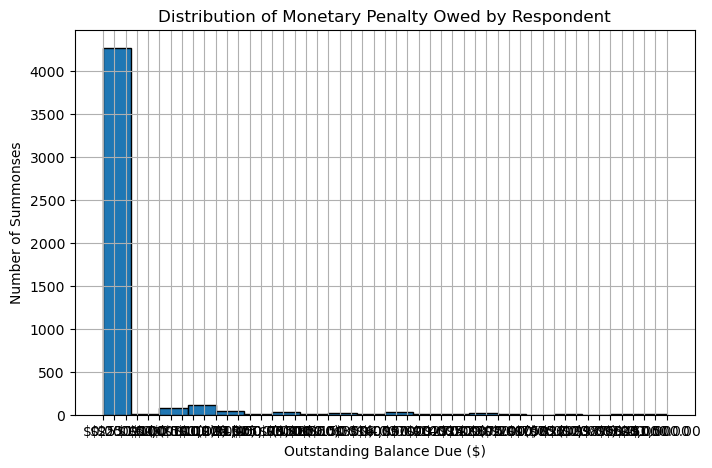

In [37]:
# O Balance Due Distribution
civil_summons_2021.O_Balance_Due.hist(
    bins=20, 
    edgecolor='black', 
    figsize=(8,5)
)
plt.title("Distribution of Monetary Penalty Owed by Respondent")
plt.xlabel("Outstanding Balance Due ($)")
plt.ylabel("Number of Summonses")

plt.savefig('EDA_figures/Distribution of Monetary Penalty Owed by Respondent.png', dpi=300, bbox_inches='tight')
plt.show()

#### O_Violation_Location_Borough: One of the five boroughs of New York City (Brooklyn, Bronx, Manhattan, Queens and Staten Island) in which the alleged violation occurred
ANALYSIS: Most citations given in Manhattan, Brooklyn, Queens. Minimal citations given in Bronx, Not NYC, and Staten Island


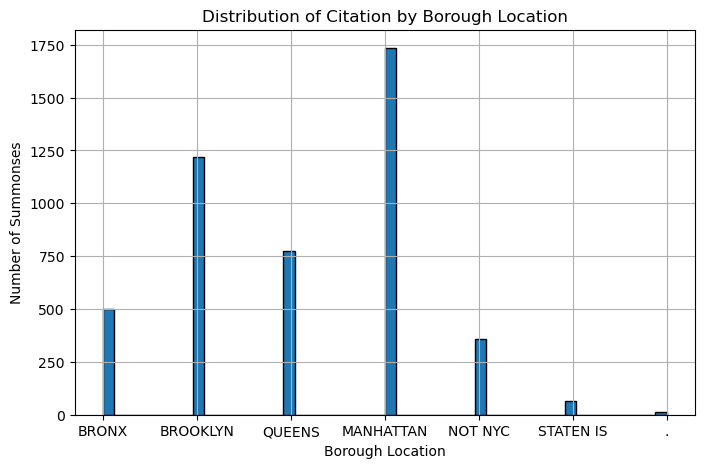

In [39]:
# Citation Borough Locations
civil_summons_2021.O_Violation_Location_Borough.hist(
    bins=50, 
    edgecolor='black', 
    figsize=(8,5)
)
plt.title("Distribution of Citation by Borough Location")
plt.xlabel("Borough Location")
plt.ylabel("Number of Summonses")


plt.savefig('EDA_figures/Distribution of Citation by Borough Location.png', dpi=300, bbox_inches='tight')
plt.show()

#### O_Violation_Location_City: Name of the City, town or community where the alleged violation occurred

**DELETE**


ANALYSIS: Too skewed for analysis; 360 missing values, has a mixture of boroughs in addition to neighborhoods. Unreliable due to location based on officer knowledge of area. 

In [41]:
civil_summons_2021['O_Violation_Location_City'].value_counts()

O_Violation_Location_City
NEW YORK           1735
BROOKLYN           1217
QUEENS              569
BRONX               502
.                   373
STATEN ISLAND        66
JAMAICA              51
LONG ISLAND CIT      25
CORONA               17
FLUSHING             17
JACKSON HEIGHTS      11
FAR ROCKAWAY          9
ASTORIA               7
SPRINGFIELD GDN       7
WOODSIDE              6
RIDGEWOOD             6
SAINT ALBANS          6
SOUTH RICHMOND        6
ELMHURST              6
COLLEGE POINT         3
FOREST HILLS          2
QUEENS VILLAGE        2
MASPETH               2
RICHMOND HILL         2
OZONE PARK            2
SOUTH OZONE PAR       2
WHITESTONE            2
FRESH MEADOWS         1
ROCKAWAY PARK         1
CAMBRIA HEIGHTS       1
KEW GARDENS           1
ARVERNE               1
WOODHAVEN             1
GLEN OAKS             1
EAST ELMHURST         1
REGO PARK             1
BAYSIDE               1
Name: count, dtype: int64

#### O_Violation_Location_Zip_Code: The zip code of the address where the alleged violation occurred

**DELETE**

ANALYSIS: Unreliable, 3,067 missing values

In [43]:
civil_summons_2021['O_Violation_Location_Zip_Code'].value_counts()

O_Violation_Location_Zip_Code
.          3079
10036.0     201
11249.0      89
11216.0      72
10001.0      71
           ... 
10112.0       1
11411.0       1
10044.0       1
11106.0       1
11361.0       1
Name: count, Length: 157, dtype: int64

#### O_Respondent_Address_Borough: The borough in which the respondent lives or is located.
ANALYSIS: More people not from NYC receive civil summons, Queens, Brooklyn. Less residents from Bronx, Manhattan, and Staten Island received civil citations in 2021.

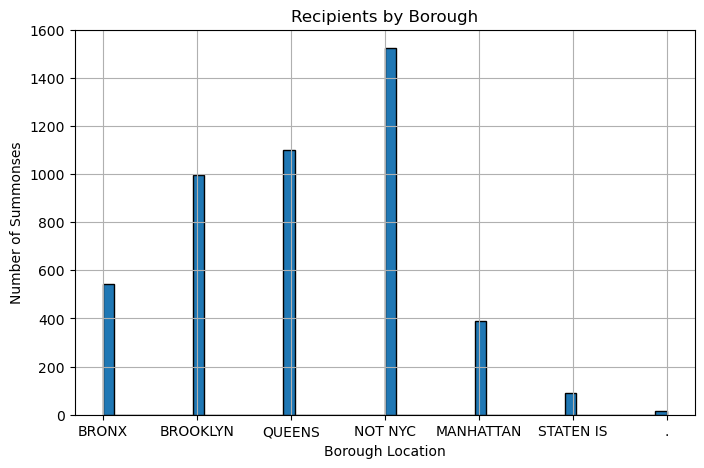

In [45]:
# Significant change 
# Citation Borough Locations
civil_summons_2021.O_Respondent_Address_Borough.hist(
    bins=50, 
    edgecolor='black', 
    figsize=(8,5)
)
plt.title("Recipients by Borough")
plt.xlabel("Borough Location")
plt.ylabel("Number of Summonses")
plt.show()

#### O_Hearing_Status: Hearing status
- Hearing Completed: hearing was completed, violation resolved
- Paid in Full: Paid, violation resolved
- Defaulted: Did not appear/Unpaid; you can either pay the default penalty or complete a Request for a New Hearing After Failure to Appear form. If your Request is granted, you will be given a date to appear for a hearing to contest the summons.
- Docketed: Unpaid; the City may attempt to collect on the money owed through court proceedings or by attaching liens to real property
- New Issuance: No respondent action yet 
- Appeal Decision Rendered: Respondend tfiled an appeal 
- Assigned: Case has been assigned to a eharing officer/respondent has not yet completed a hearing 

ANALYSIS: 2430 of the hearings were complete; 964 were paid in full; 775 were defaulted; 385 were docketed; 103 were new issuances; 5 appealed: 1 assigned 

In [47]:
civil_summons_2021['O_Hearing_Status'].value_counts()

O_Hearing_Status
HEARING COMPLETED       2431
PAID IN FULL             969
DEFAULTED                763
DOCKETED                 378
NEW ISSUANCE             102
.                         14
APPEAL DECIS RENDERD       5
ASSIGNED                   1
Name: count, dtype: int64

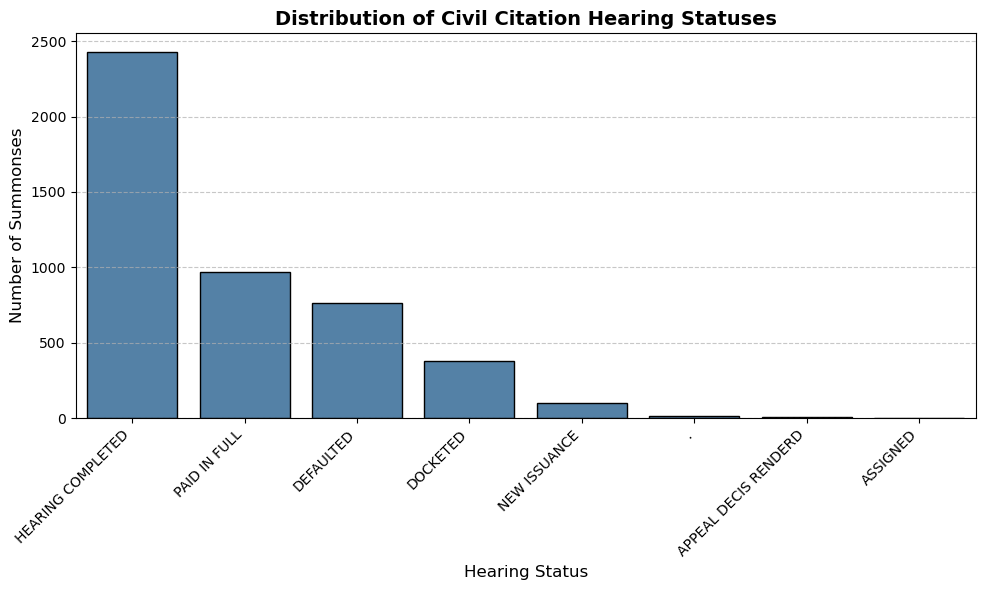

In [48]:
# O hearing Status Distribution
status_counts = civil_summons_2021['O_Hearing_Status'].value_counts().reset_index()
status_counts.columns = ['Hearing Status', 'Number of Summonses']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=status_counts, 
    x='Hearing Status', 
    y='Number of Summonses', 
    color='steelblue', 
    edgecolor='black'
)

plt.title("Distribution of Civil Citation Hearing Statuses", fontsize=14, fontweight='bold')
plt.xlabel("Hearing Status", fontsize=12)
plt.ylabel("Number of Summonses", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('EDA_figures/Distribution of Civil Citation Hearing Statuses.png', dpi=300, bbox_inches='tight')
plt.show()


#### O_Hearing_Result: Outcome or result of the hearing 

**DELETE**

ANALYSIS: 844 missing results; 2377 were dismissed; 1161 defaulted; 250 in violation; 27 settled in-vio; 4 adjourned 

In [50]:
civil_summons_2021['O_Hearing_Result'].value_counts()

O_Hearing_Result
DISMISSED       2377
DEFAULTED       1145
.                857
IN VIOLATION     250
SETTL IN-VIO      30
ADJOURNED          4
Name: count, dtype: int64

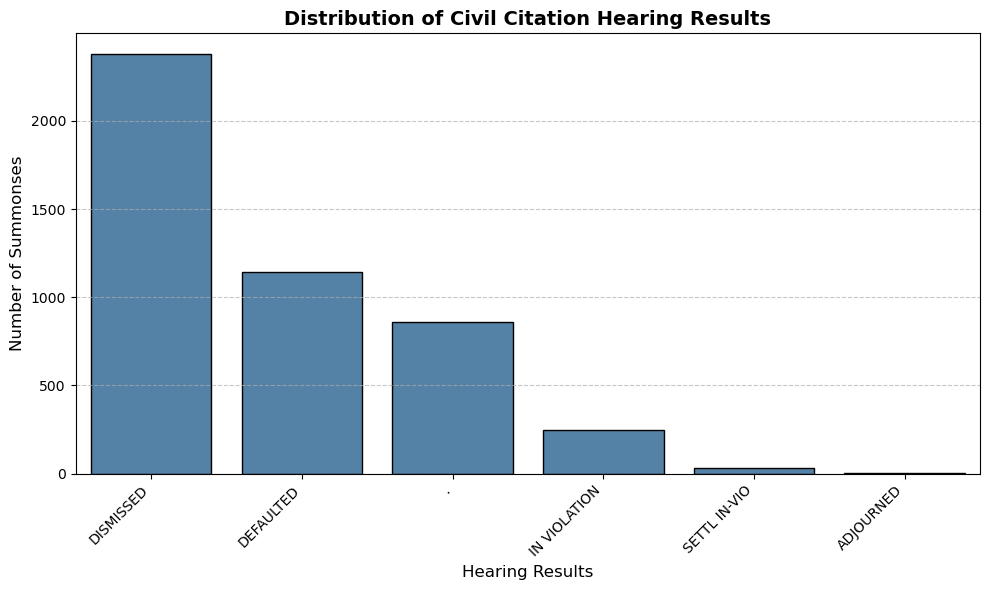

In [51]:
# O_Hearing_Results 
status_counts = civil_summons_2021['O_Hearing_Result'].value_counts().reset_index()
status_counts.columns = ['Hearing Result', 'Number of Summonses']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=status_counts, 
    x='Hearing Result', 
    y='Number of Summonses', 
    color='steelblue', 
    edgecolor='black'
)

plt.title("Distribution of Civil Citation Hearing Results", fontsize=14, fontweight='bold')
plt.xlabel("Hearing Results", fontsize=12)
plt.ylabel("Number of Summonses", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('EDA_figures/Distribution of Civil Citation Hearing Results.png', dpi=300, bbox_inches='tight')
plt.show()


#### O_Total_Violation_Amount: The monetary amount associated with the violation
ANALYSIS: This is total violation amount charged; most are around 250, 0, 25, 100. 

In [53]:
civil_summons_2021['O_Total_Violation_Amount'].value_counts()

O_Total_Violation_Amount
$250.00       1551
$0.00         1065
$25.00         812
$100.00        432
$50.00         215
$1,000.00      145
$75.00         129
$350.00         53
$280.00         49
$500.00         41
$560.00         29
$200.00         25
$140.00         23
$15,000.00      17
.               14
$70.00          13
$4,000.00       11
$750.00          8
$210.00          7
$880.00          5
$150.00          4
$220.00          4
$1,200.00        3
$5,000.00        2
$2,300.00        1
$840.00          1
$1,500.00        1
$300.00          1
$2,500.00        1
$440.00          1
Name: count, dtype: int64

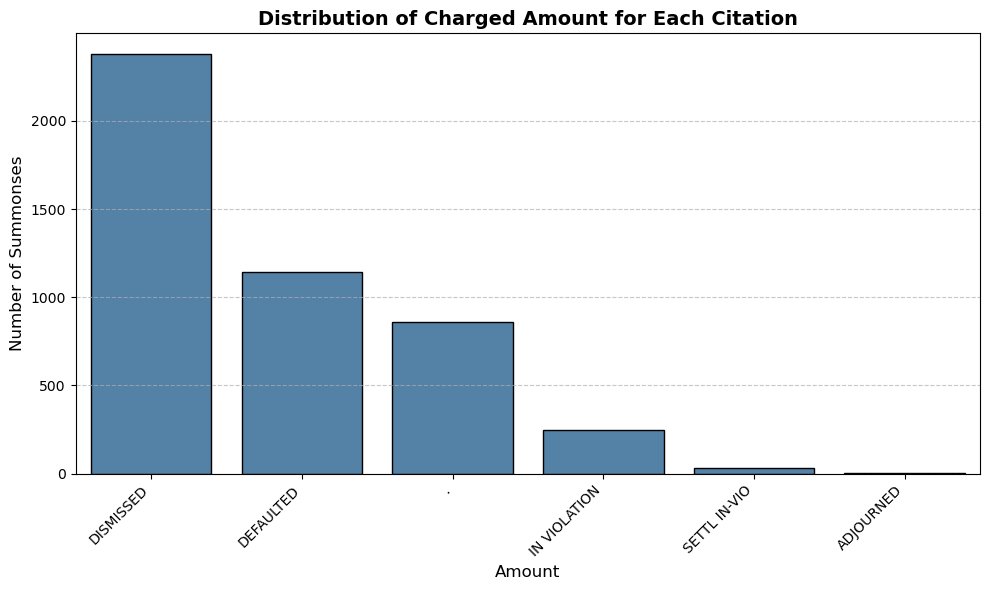

In [54]:
data = civil_summons_2021['O_Total_Violation_Amount'].value_counts().reset_index()
data.columns = ['Hearing Result', 'Number of Summonses']

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    data=status_counts, 
    x='Hearing Result', 
    y='Number of Summonses', 
    color='steelblue', 
    edgecolor='black'
)

plt.title("Distribution of Charged Amount for Each Citation", fontsize=14, fontweight='bold')
plt.xlabel("Amount", fontsize=12)
plt.ylabel("Number of Summonses", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('EDA_figures/Distribution of Charged Amount for Each Citation.png', dpi=300, bbox_inches='tight')
plt.show()

#### O_Payment_Status <- O_Penalty_Imposed: The actual penalty the respondent is required to pay & O_Paid_Amount: The total amount paid by the respondent

ANALYSIS: Different from hearing status, directly indicates willingness to pay. Created a new variable "Payment-Status" which shows that 2519 had no penalty imposed, 1152 unpaid, 853 paid in full; 62 missing data; 58 overpaid/adjustment; 19 partially paid

In [56]:
civil_summons_2021['O_Penalty_Imposed'].value_counts()

O_Penalty_Imposed
$0.00         2518
$25.00         817
$250.00        594
$100.00        266
$50.00         117
$112.00        103
$1,000.00       51
$500.00         32
$75.00          32
$280.00         26
$350.00         17
.               14
$150.00         10
$140.00          8
$400.00          6
$560.00          6
$375.00          5
$750.00          4
$70.00           4
$300.00          4
$200.00          3
$1,500.00        2
$1,400.00        2
$2,000.00        2
$5.00            2
$1,200.00        2
$700.00          2
$170.00          1
$3,000.00        1
$450.00          1
$310.00          1
$210.00          1
$875.00          1
$1.00            1
$175.00          1
$10.00           1
$220.00          1
$15,000.00       1
$880.00          1
$4,000.00        1
$440.00          1
Name: count, dtype: int64

In [57]:
civil_summons_2021['O_Paid_Amount'].value_counts()

O_Paid_Amount
$0.00        3623
$250.00       517
$100.00       205
$50.00         91
$25.00         32
             ... 
$1,203.00       1
$313.00         1
$751.00         1
$375.00         1
$304.00         1
Name: count, Length: 71, dtype: int64

In [58]:

civil_summons_2021['O_Penalty_Imposed'] = pd.to_numeric(
    civil_summons_2021['O_Penalty_Imposed']
        .astype(str)
        .str.replace(r'[$,]', '', regex=True)
        .str.strip()
        .replace({'': None, '.': None}),
    errors='coerce'
)

civil_summons_2021['O_Paid_Amount'] = pd.to_numeric(
    civil_summons_2021['O_Paid_Amount']
        .astype(str)
        .str.replace(r'[$,]', '', regex=True)
        .str.strip()
        .replace({'': None, '.': None}),
    errors='coerce'
)


In [59]:
civil_summons_2021['O_Penalty_Imposed']

0         0.0
1         0.0
2       250.0
3         0.0
4       250.0
        ...  
4658    500.0
4659      0.0
4660      0.0
4661      0.0
4662      0.0
Name: O_Penalty_Imposed, Length: 4663, dtype: float64

In [60]:
civil_summons_2021['Amount_Difference'] = (
    civil_summons_2021['O_Penalty_Imposed'] - civil_summons_2021['O_Paid_Amount']
)
civil_summons_2021['Amount_Difference']

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
        ...  
4658    500.0
4659      0.0
4660      0.0
4661      0.0
4662      0.0
Name: Amount_Difference, Length: 4663, dtype: float64

In [61]:
# There are 14 tickets that Oath has not accounted for
civil_summons_2021['O_Paid_Amount'].isna().sum()

14

In [62]:
# Function for binning into paid categories
def payment_status(row):
    if pd.isna(row['O_Penalty_Imposed']) or pd.isna(row['O_Paid_Amount']):
        return "Missing Data"
    if row['O_Penalty_Imposed'] == 0:
        return "No Penalty Imposed"
    if row['O_Paid_Amount'] == 0:
        return "Unpaid"
    if row['O_Paid_Amount'] == row['O_Penalty_Imposed']:
        return "Paid in Full"
    if row['O_Paid_Amount'] < row['O_Penalty_Imposed']:
        return "Partially Paid"
    if row['O_Paid_Amount'] > row['O_Penalty_Imposed']:
        return "Overpaid / Adjustment"
        
civil_summons_2021['O_Payment_Status'] = civil_summons_2021.apply(payment_status, axis=1)

In [63]:
civil_summons_2021['O_Payment_Status'].value_counts()

O_Payment_Status
No Penalty Imposed       2518
Unpaid                   1163
Paid in Full              879
Overpaid / Adjustment      66
Partially Paid             23
Missing Data               14
Name: count, dtype: int64

#### O_Compliance_Status: Indicates whether the respondent has taken measures to address the summons
ANALYSIS: 3369 have all terms met; 1289 have a penalty due; 5 have both due

In [65]:
civil_summons_2021['O_Compliance_Status'].value_counts()

O_Compliance_Status
All Terms Met    3374
Penalty Due      1270
.                  14
Both Due            5
Name: count, dtype: int64

#### O_Final_Charge <- 

#### O_Charge1_Code: The OATH Code for the first charge noted
#### O_Charge2_Code: The OATH Code for the second charge noted
#### O_Charge3_Code: The OATH Code for the third charge noted


ANALYSIS: Some respondents have no first charge but a second charge: 3,863 codes in the first charge, 611 codes in the second charge; 25 charges in the third charge. Total 226 tickets without charges. Compiled all three to create a "Final_Charge" column. Those with multiple charges are compiled into a string list in Final_Charge. 

In [67]:
# Charge 1 Violation 
civil_summons_2021.O_Charge1_Code.count()

4663

In [68]:
# How many codes are in each charge
# O_Charge1_Code = has the most charges
civil_summons_2021[['O_Charge1_Code', 'O_Charge2_Code', 'O_Charge3_Code']].replace('.', pd.NA).notna().sum()

O_Charge1_Code    3777
O_Charge2_Code     687
O_Charge3_Code      22
dtype: int64

In [69]:
# Distribution of O_Charge1_Code_Description
# 1,422 citations for Failure to Yield, 804 for Open Container Consumption of Alcohol on Streets 

civil_summons_2021.O_Charge1_Code_Description.value_counts(dropna=False).head(25)

O_Charge1_Code_Description
RIGHT OF WAY - FAILURE TO YIELD, PHYSICAL INJURY                       1434
.                                                                       893
OPEN CONTAINER CONSUMPTION OF ALCOHOL ON STREETS                        792
RIGHT OF WAY - FAILURE TO YIELD                                         367
PUBLIC URINATION 1ST OFFENSE                                             93
VENDING AT TIME OR PLACE PROHIBITED                                      90
FAILURE TO DISPLAY LICENSE OR PLATE                                      88
VENDING IN BUS STOP, SIDEWALK NEXT TO A HOSPITAL OR HEALTH FACILITY      74
IDLING OF MOTOR VEHICLE ENGINE MORE THAN THREE MINUTES 1ST OFF           46
UNLICENSED GENERAL VENDOR ACTIVITY                                       42
IMPROPER AUDIBLE BURGLAR ALARM WITH NO AUTOMATIC TERMINATION             39
FAIL TO COMPLY WITH MOTOR SCOOTER REQUIREMENTS                           38
UNLAWFUL BICYCLE RIDING ON SIDEWALK                          

In [70]:
# Distribution of O_Charge2_Code_Description
civil_summons_2021.O_Charge2_Code_Description.value_counts(dropna=False).head(25)

O_Charge2_Code_Description
.                                                                         3982
FAILURE TO DISPLAY LICENSE OR PLATE                                        127
RIGHT OF WAY - FAILURE TO YIELD, PHYSICAL INJURY                           118
VENDING AT TIME OR PLACE PROHIBITED                                        115
VENDING IN BUS STOP, SIDEWALK NEXT TO A HOSPITAL OR HEALTH FACILITY         98
ITEMS NOT IN OR UNDER CART EXCEPT WASTE CONTAINER                           38
RIGHT OF WAY - FAILURE TO YIELD                                             32
UNCODED LAW, RULE, OR REGULATION                                            31
VENDING ON SIDEWALK LESS THAN 12 FT., OR NOT AT CURB                        28
OPERATING A MFVU IN ANY PUBLIC SPACE WITHOUT A LICENSE                      16
OPEN CONTAINER CONSUMPTION OF ALCOHOL ON STREETS                            14
NYC HEALTH CODE PROVISION - MISCELLANEOUS                                   14
PUBLIC URINATION 1ST OFFE

In [71]:
civil_summons_2021.O_Charge3_Code_Description.value_counts(dropna=False).head(25)

O_Charge3_Code_Description
.                                                                    4645
VENDING AT TIME OR PLACE PROHIBITED                                     5
FAILURE TO DISPLAY LICENSE OR PLATE                                     3
ITEMS NOT IN OR UNDER CART EXCEPT WASTE CONTAINER                       3
UNLAWFUL BICYCLE RIDING ON SIDEWALK                                     2
RIGHT OF WAY - FAILURE TO YIELD                                         2
FAILURE TO PROVIDE WORKING PUBLIC PAY TELEPHONE OPERATOR SERVICES       1
RIGHT OF WAY - FAILURE TO YIELD, PHYSICAL INJURY                        1
UNCODED LAW, RULE, OR REGULATION                                        1
Name: count, dtype: int64

In [72]:
# Making a final charge column 
charge_cols = [
    'O_Charge1_Code_Description',
    'O_Charge2_Code_Description',
    'O_Charge3_Code_Description'
]

def combine_all_charges(row):
    charges = [row[col] for col in charge_cols if row[col] != "."]
    return "; ".join(charges) if charges else "."
    
civil_summons_2021['O_Final_Charge'] = civil_summons_2021.apply(combine_all_charges, axis=1)

In [73]:
civil_summons_2021['O_Final_Charge'].value_counts()

O_Final_Charge
RIGHT OF WAY - FAILURE TO YIELD, PHYSICAL INJURY                                                            1529
OPEN CONTAINER CONSUMPTION OF ALCOHOL ON STREETS                                                             806
RIGHT OF WAY - FAILURE TO YIELD                                                                              387
.                                                                                                            239
FAILURE TO DISPLAY LICENSE OR PLATE                                                                          212
                                                                                                            ... 
VENDING IN BUS STOP, SIDEWALK NEXT TO A HOSPITAL OR HEALTH FACILITY; FAILURE TO DISPLAY LICENSE OR PLATE       1
UNREASONABLE NOISE FROM ENGINE EXHAUST; UNREASONABLE NOISE FROM CONSTRUCTION DEVICES-3RD                       1
FAILURE TO DISPLAY LICENSE OR PLATE; UNCODED LAW, RULE, OR REGULATION            

In [74]:
# How many have no charge? 
(civil_summons_2021[
    (civil_summons_2021['O_Charge1_Code_Description'] == ".") &
    (civil_summons_2021['O_Charge2_Code_Description'] == ".") &
    (civil_summons_2021['O_Charge3_Code_Description'] == ".")
].shape[0])


239

#### DA_charge: Description of disciplinary charge against PO
#### DA_disposition: Description of disciplinary charge against PO

#### CC_charge: Description of disciplinary charge against PO
#### CC_disposition: Description of disciplinary charge against PO

ANALYSIS: Overlap; Necessary in assessing officer behavior. Created a final_discipline_charge and final_discipline_disp column. Is this necessary for analysis when we have CCRB FADO? This is not CCRB, but nype 

In [76]:
civil_summons_2021['DA_charge'].value_counts()

DA_charge
.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [77]:
civil_summons_2021['CC_charge'].value_counts()

CC_charge
.                                                                                                                                                                                                                                                                                                                                                                                                                                                        4508
["WHILE OFF DUTY FAILED TO REPORT SAID INCIDENT TO MEMBER'S COMMANDING OFFICER ."]                                                                                                                                                                                                                                                                                                                                                                         17
['FAILED TO APPEAR FOR HIS SCHEDULED TOUR OF DUTY.', 'FAILED TO REPORT TO HIS DISTRICT SURGON AS D

In [78]:
civil_summons_2021['DA_disposition'].value_counts()

DA_disposition
.                                                                                                                                                                                                                                                                                                                                                                                                       4644
['GUILTY']                                                                                                                                                                                                                                                                                                                                                                                                 5
['GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY']                                                                                                                                             

In [79]:
civil_summons_2021['CC_disposition'].value_counts()

CC_disposition
.                                                                                               4508
['GUILTY']                                                                                        51
['GUILTY', 'GUILTY', 'GUILTY']                                                                    27
['GUILTY', 'GUILTY', 'GUILTY', 'GUILTY']                                                          23
['GUILTY', 'GUILTY']                                                                              18
['GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY']                                                11
['PLEADED GUILTY']                                                                                 5
['GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY']                                       4
['GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY', 'GUILTY']                             4
['PLEADED GUILTY', 'PLEADED GUILTY', 'PLEADED GUILTY', 'PLEADED GUILTY', 'PL

In [80]:
civil_summons_2021['DA_penalty'].value_counts()

DA_penalty
.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [81]:
# Making final_discipline_charge
charge_cols = ['DA_charge', 'CC_charge']

def combine_all_charges(row):
    charges = []

    for col in charge_cols:
        value = row[col]
        if value not in [".", None, "", " "] and pd.notna(value):
            charges.append(value.strip())

    # remove duplicates, preserve order
    charges = list(dict.fromkeys(charges))

    # return "." if no real charges
    if len(charges) == 0:
        return "."

    return "; ".join(charges)

civil_summons_2021['Full_Charge'] = civil_summons_2021.apply(combine_all_charges, axis=1)


In [82]:
civil_summons_2021['Full_Charge'].value_counts()

Full_Charge
.                                                                                                                                                                                                                                                                                                                                                                                                                                                        4507
["WHILE OFF DUTY FAILED TO REPORT SAID INCIDENT TO MEMBER'S COMMANDING OFFICER ."]                                                                                                                                                                                                                                                                                                                                                                         17
['FAILED TO APPEAR FOR HIS SCHEDULED TOUR OF DUTY.', 'FAILED TO REPORT TO HIS DISTRICT SURGON AS

In [83]:
# Category Bins fo Diciplinary History 

[
 "Excessive Force",
 "Abuse of Authority",
 "Neglect of Duty",
 "False Statements / Records",
 "Unfit for Duty / Alcohol",
 "Firearms Misconduct",
 "Misuse of Resources / Time",
 "Off-Duty Misconduct (Non-Force)"
]


['Excessive Force',
 'Abuse of Authority',
 'Neglect of Duty',
 'False Statements / Records',
 'Unfit for Duty / Alcohol',
 'Firearms Misconduct',
 'Misuse of Resources / Time',
 'Off-Duty Misconduct (Non-Force)']

#### First Set: All deleted; no relevance for analysis, duplicate variables
- FS_first_name 
- FS_middle_name
- FS_last_name
- FS_shield 


#### Disciplinary History
    -KEPT: DH_charge_count (Number of disciplinary charges made against PO), DH_allegation_count(Number of disciplinary allegations made against PO)
    -DELETED: DH_date

In [86]:
civil_summons_2021.DH_charge_count.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4663 entries, 0 to 4662
Series name: DH_charge_count
Non-Null Count  Dtype 
--------------  ----- 
4663 non-null   object
dtypes: object(1)
memory usage: 36.6+ KB


In [87]:
civil_summons_2021['DH_charge_count'].value_counts().sort_index()

DH_charge_count
.                  4507
['.', '.']            4
[1.0, '.']            1
[1.0, 2.0, 1.0]       1
[1.0, 4.0]            1
[1.0, 6.0]            1
[1.0]                54
[10.0]                3
[2.0, 1.0]            4
[2.0]                19
[3.0, '.']            1
[3.0, 1.0]            1
[3.0, 2.0]            1
[3.0, 3.0]            1
[3.0]                23
[4.0, 1.0]            1
[4.0]                23
[5.0, 1.0, '.']       1
[5.0]                 9
[6.0]                 4
[7.0]                 3
Name: count, dtype: int64

In [88]:
officer_charge_dist = civil_summons_2021.groupby("Final_Officer_Tax_ID")["DH_charge_count"].sum()

In [89]:
officer_charge_dist.describe()


count     2423
unique      65
top          .
freq      1637
Name: DH_charge_count, dtype: object

In [90]:
officer_charge_dist.sort_values(ascending=False).head(20)

Final_Officer_Tax_ID
935629                                                [7.0]
933518                                                [7.0]
960924                                                [7.0]
952322                                 [6.0][6.0][6.0][6.0]
961381                                      [5.0][5.0][5.0]
935312                                      [5.0][5.0][5.0]
942214                                                [5.0]
933282                                                [5.0]
947721                                                [5.0]
953658                                      [5.0, 1.0, '.']
962062    [4.0][4.0][4.0][4.0][4.0][4.0][4.0][4.0][4.0][...
945466                  [4.0][4.0][4.0][4.0][4.0][4.0][4.0]
953289                                                [4.0]
929928                                                [4.0]
954718                                                [4.0]
962446                                                [4.0]
939265             

In [91]:
civil_summons_2021['CC_charge'].value_counts().sort_index()

CC_charge
.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           4508
["WHILE OFF DUTY FAILED TO REPORT SAID INCIDENT TO MEMBER'S COMMANDING OFFICER ."]                                                                                                                                                                                                                                                                                                                                                           

In [92]:
civil_summons_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Columns: 105 entries, Ticket_Number to Full_Charge
dtypes: datetime64[ns](1), float64(5), int64(8), object(91)
memory usage: 3.7+ MB


#### aa_felony_arrest_count
#### aa_infraction_arrest_count
#### aa_misdemeanor_arrest_count
#### aa_other_arrest_count
#### aa_violation_arrest_count
ANALYSIS: Necessary numeric indicator for behavior/enforcement style. Some officer have 1,380 misdemeanors arrest, 229 felony arrests, 248 violation arrests, 49 infraction arrests, and 11 other arrests. 

In [94]:
arrest_cols = [
    'aa_felony_arrest_count',
    'aa_infraction_arrest_count',
    'aa_misdemeanor_arrest_count',
    'aa_other_arrest_count',
    'aa_violation_arrest_count'
]

civil_summons_2021[arrest_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
aa_felony_arrest_count,4663.0,20.085567,30.502551,0.0,5.0,11.0,23.0,229.0
aa_infraction_arrest_count,4663.0,0.480592,1.631547,0.0,0.0,0.0,0.0,49.0
aa_misdemeanor_arrest_count,4663.0,59.141325,68.221461,0.0,19.0,40.0,76.0,1380.0
aa_other_arrest_count,4663.0,0.049968,0.333127,0.0,0.0,0.0,0.0,11.0
aa_violation_arrest_count,4663.0,8.081278,21.197010,0.0,0.0,1.0,5.0,248.0


#### AR_award_date: not neccessary for analysis 
#### AR_award_type

**KEEP** 

ANALYSIS: Award date is unnecessary for analysis. There are 14 types of awards: 
- COMMENDATION
- COMMENDATION-COMMUNITY SERVICE
- COMMENDATION-INTEGRITY
- EXCELLENT POLICE DUTY
- EXCEPTIONAL MERIT
- HONORABLE MENTION
- MEDAL FOR MERIT
- MEDAL FOR VALOR
- MEDAL OF HONOR
- MERITORIOUS POLICE DUTY
- MERITORIOUS POLICE DUTY-INTEGRITY
- POLICE COMBAT CROSS
- PURPLE SHIELD MEDAL 
- UNIT CITATION 

However, our officers only hold 5 awards: 
- EXCELLENT POLICE DUTY                5642
- MERITORIOUS POLICE DUTY              1950
- COMMENDATION                           77
- MERITORIOUS POLICE DUTY-INTEGRITY       3
- EXCEPTIONAL MERIT                       1

Bin these down into 4 categoris for dummy variables: 
- "commendation_award_count",
- "excellent_award_count",
- "meritorious_award_count",
- "meritorious_integrity_award_count",
- "exceptional_merit_award_count"

Added master_dept_recognitions -> total_award_count 


In [96]:
civil_summons_2021["AR_award_type"].value_counts()

AR_award_type
.                                                                                                                                                                                                                                                                                                                                                                                                                                       2647
['EXCELLENT POLICE DUTY']                                                                                                                                                                                                                                                                                                                                                                                                                701
['EXCELLENT POLICE DUTY', 'EXCELLENT POLICE DUTY']                                                                              

In [97]:
# Fix the format 
import ast

def ensure_list(x):
    if x == ".":
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except:
        return []
        
civil_summons_2021["AR_award_type"] = civil_summons_2021["AR_award_type"].apply(ensure_list)


In [98]:
# Check distribution of awards in our dataset
# There's only 5 our of the 14 awards shown for our officers
df_awards = civil_summons_2021.copy()

df_awards["AR_award_type"] = df_awards["AR_award_type"].apply(
    lambda x: x if len(x) > 0 else None
)

# Explode into one row per award
exploded = df_awards.explode("AR_award_type")

# Count awards
award_counts = exploded["AR_award_type"].value_counts()

award_counts


AR_award_type
EXCELLENT POLICE DUTY                5642
MERITORIOUS POLICE DUTY              1950
COMMENDATION                           77
MERITORIOUS POLICE DUTY-INTEGRITY       3
EXCEPTIONAL MERIT                       1
Name: count, dtype: int64

In [99]:
exploded = df_awards.explode("AR_award_type")


In [100]:
award_counts = exploded["AR_award_type"].value_counts()

award_counts

AR_award_type
EXCELLENT POLICE DUTY                5642
MERITORIOUS POLICE DUTY              1950
COMMENDATION                           77
MERITORIOUS POLICE DUTY-INTEGRITY       3
EXCEPTIONAL MERIT                       1
Name: count, dtype: int64

In [101]:
# Making new columns per award
award_column_map = {
    "COMMENDATION": "commendation_award_count",
    "EXCELLENT POLICE DUTY": "excellent_award_count",
    "MERITORIOUS POLICE DUTY": "meritorious_award_count",
    "MERITORIOUS POLICE DUTY-INTEGRITY": "meritorious_integrity_award_count",
    "EXCEPTIONAL MERIT": "exceptional_merit_award_count"
}

# Create new count columns
for award, col_name in award_column_map.items():
    civil_summons_2021[col_name] = civil_summons_2021["AR_award_type"].apply(
        lambda lst: lst.count(award)
    )


In [102]:
# list all award count columns
award_count_cols = [
    "commendation_award_count",
    "excellent_award_count",
    "meritorious_award_count",
    "meritorious_integrity_award_count",
    "exceptional_merit_award_count"
]

# make table of totals
award_summary_table = civil_summons_2021[award_count_cols].sum().reset_index()

# rename columns
award_summary_table.columns = ["award_type", "total_count"]

award_summary_table



,award_type,total_count
0,commendation_award_count,77
1,excellent_award_count,5642
2,meritorious_award_count,1950
3,meritorious_integrity_award_count,3
4,exceptional_merit_award_count,1


In [103]:
civil_summons_2021[["Final_Officer_Tax_ID"] + award_count_cols]


,Final_Officer_Tax_ID,commendation_award_count,excellent_award_count,meritorious_award_count,meritorious_integrity_award_count,exceptional_merit_award_count
0,953430,0,1,0,0,0
1,961743,0,0,0,0,0
2,961465,0,0,0,0,0
3,964085,0,0,0,0,0
4,964778,0,0,0,0,0
...,...,...,...,...,...,...
4658,952535,0,1,0,0,0
4659,953330,0,0,0,0,0
4660,948461,0,3,0,0,0
4661,948461,0,3,0,0,0


In [104]:
#### master_dept_recognitions -> total_award_count 

civil_summons_2021 = civil_summons_2021.rename(
    columns={"master_dept_recognitions": "total_award_count"}
)


In [105]:
# Checking rename
civil_summons_2021.total_award_count.head(10)

0    1.0
1    0.0
2    0.0
3    0.0
4    0.0
5    1.0
6    0.0
7    0.0
8    0.0
9    4.0
Name: total_award_count, dtype: object

#### AD Allegations : we are using CCRB allegation data for this analysis / could categorize these for later analysis
**DELETED** 


#### master_command: PO command derived from First Set, Personnel File and Discplinary Actions with preference given to First Set for dissimilar commands listed

**DELETED & FIXED**

ANALYSIS: Use this


In [108]:
civil_summons_2021["master_command"].value_counts().head(50)

master_command
BUSINESS IMPROVEMENT DEPLOYMENT TEAM    455
079 PRECINCT                            196
090 PRECINCT                            180
TIMES SQUARE UNIT                       180
014 PCT-MIDTOWN SO. PCT                 174
018 PCT-MIDTOWN NO. PCT                 108
109 PRECINCT                            101
070 PRECINCT                             77
081 PRECINCT                             75
CRITICAL RESPONSE COMMAND                72
STRATEGIC RESP GRP 4 QUEENS              69
066 PRECINCT                             69
025 PRECINCT                             64
043 PRECINCT                             58
001 PRECINCT                             54
077 PRECINCT                             52
105 PRECINCT                             51
102 PRECINCT                             50
023 PRECINCT                             50
045 PRECINCT                             50
005 PRECINCT                             49
019 PRECINCT                             49
113 PRECINCT     

#### master_rank: PO most recent rank derived from First Set, Personnel File and Discplinary Actions with preference given to the rank attached to the most recent date

**DELETED & FIXED**

ANALYSIS: 4,270 police officers, 230 detectives, 125 seargants, 35 unknown, and 1 captain

In [110]:
civil_summons_2021["master_rank"].value_counts().head()

master_rank
POLICE OFFICER    4270
DETECTIVE          230
SERGEANT           125
.                   35
CAPTAIN              1
Name: count, dtype: int64

#### aa_total_arrests <- : PO total arrests as of most recent web scraping. Derived from First Set and Personnel File with preference given to the First Set but Personnel File will be used if there are no arrests in First Set

**KEPT**

ANALYSIS: 4,270 police officers, 230 detectives, 125 seargants, 35 unknown, and 1 captain

In [112]:
civil_summons_2021.groupby("Final_Officer_Tax_ID")["total_arrests"].describe()


,count,unique,top,freq
Final_Officer_Tax_ID,,,,
886546,1,1,.,1
902524,1,1,.,1
916969,1,1,249.0,1
917525,4,1,.,4
919008,3,1,246.0,3
...,...,...,...,...
971697,2,1,16.0,2
971700,2,1,12.0,2
971730,2,1,7.0,2


In [113]:
# Make numeric
civil_summons_2021["aa_total_arrests"] = pd.to_numeric(
    civil_summons_2021["total_arrests"], errors="coerce"
)

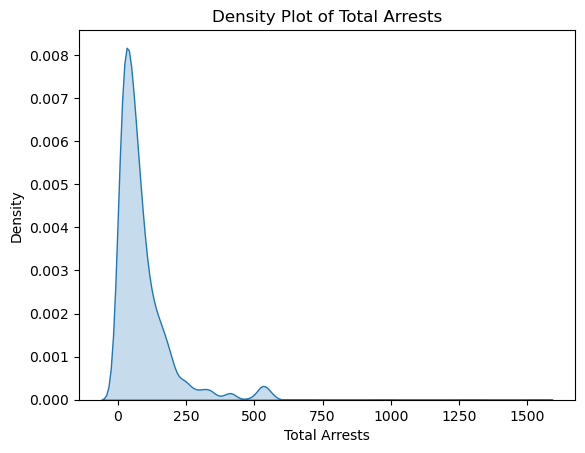

In [114]:
# Density Plot
sns.kdeplot(civil_summons_2021["aa_total_arrests"], fill=True)
plt.title("Density Plot of Total Arrests")
plt.xlabel("Total Arrests")
plt.ylabel("Density")

plt.savefig('EDA_figures/Density Plot of Total Arrests.png', dpi=300, bbox_inches='tight')
plt.show()



#### final_race: PO race/ethnicity. Derived from First Set and Personnel File with preference given to the First Set but Personnel File will be used if there is no race/ethnicity listed in First Set. 
**DELETED & FIXED**


ANALYSIS: Had to directly pull from Legal AID rster; too many missing race values (35), now there are only 3 unmatched

In [116]:
# fixing the period
civil_summons_2021["final_race"] = civil_summons_2021["final_race"].str.strip()

In [117]:
civil_summons_2021["Final_Officer_Tax_ID"] = (
    civil_summons_2021["Final_Officer_Tax_ID"]
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
)

civil_summons_2021.loc[civil_summons_2021["Final_Officer_Tax_ID"] == ".", "Final_Officer_Tax_ID"] = None


In [118]:
# The 37 are not accounted for, let me grab that from the legal aid roster 
civil_summons_2021.final_race.value_counts()

final_race
WHITE              1940
HISPANIC           1406
BLACK               638
ASIAN               637
.                    37
NATIVE AMERICAN       5
Name: count, dtype: int64

In [119]:
missing_race_df = civil_summons_2021[civil_summons_2021["final_race"] == "."]
missing_race_df.shape

(37, 111)

In [120]:
missing_tax_ids = missing_race_df["Final_Officer_Tax_ID"].unique().tolist()
missing_tax_ids

['966888',
 '960914',
 '957044',
 '957091',
 '923153',
 '964321',
 '967441',
 '960415',
 '958908',
 '917525',
 '971383',
 '954345',
 '954342',
 '967672',
 '962521',
 '968633',
 '940914',
 '946259',
 '902524',
 '968685',
 '971093',
 '960412',
 '958500',
 '941929',
 '969126',
 '886546',
 '965034',
 '960217',
 '941041',
 '947715',
 '963020',
 '971394']

In [121]:
cs_tax_ids = civil_summons_2021["Final_Officer_Tax_ID"].unique().tolist()
cs_tax_ids

['953430',
 '961743',
 '961465',
 '964085',
 '964778',
 '963591',
 '963656',
 '952904',
 '966902',
 '966375',
 '966645',
 '964591',
 '966613',
 '966888',
 '966858',
 '966441',
 '966548',
 '966728',
 '959907',
 '960914',
 '965833',
 '956627',
 '967292',
 '961052',
 '951992',
 '961260',
 '967847',
 '968485',
 '948461',
 '948037',
 '968548',
 '969020',
 '968253',
 '968451',
 '968654',
 '956428',
 '963042',
 '964095',
 '939119',
 '949575',
 '965045',
 '966035',
 '966753',
 '958228',
 '966025',
 '966001',
 '966053',
 '966012',
 '966762',
 '966811',
 '969390',
 '964386',
 '968584',
 '966304',
 '967309',
 '959372',
 '967836',
 '968528',
 '965539',
 '958186',
 '967227',
 '945652',
 '958388',
 '941268',
 '957754',
 '968804',
 '967943',
 '962977',
 '948703',
 '956957',
 '958896',
 '965991',
 '951790',
 '966627',
 '965984',
 '953048',
 '957044',
 '949760',
 '961341',
 '969414',
 '956493',
 '952794',
 '963454',
 '966594',
 '960041',
 '964803',
 '961758',
 '953887',
 '967662',
 '965153',
 '944628',

### Merging Legal Aid Roster Data: 

Current.rank Map: 
"1": "CAPTAIN",
"2": "CHIEFS AND OTHER RANKS",
"3": "DEPUTY INSPECTOR",
"4": "DETECTIVE",
"5": "INACTIVE RANKS",
"6": "INSPECTOR",
"7": "LIEUTENANT",
"8": "POLICE OFFICER",
"9": "SERGEANT"

Race Map: 
"1": "AMERICAN INDIAN",
"2": "ASIAN",
"3": "BLACK",
"4": "HISPANIC",
"5": "OTHER RACE",
"6": "WHITE"

Gender Map: 
"1": "FEMALE",
"2": "MALE",
"3": "TGNC / OTHER"


ANALYSIS: Use these rank, command, race, gender, instead of the presious ones. Previously 35 officers were unaccounted for, now this merge with the most active roster 3 officer are unaccounted for. 

In [123]:
# There was a missing 35 from FS and PF, I directly pulled from Legal Aid NYPD Roster to get the most accurate and filled data
# I want Current.rank, Current.command, Race, Gender
roster_2021 = pd.read_csv(
    "data/roster.tsv",
    sep="\t",
    dtype=str
)

# attach to see how many internal misconduct record with our officers 
matched_ids = roster_2021[roster_2021["Tax.."].isin(cs_tax_ids)]

In [124]:
len(cs_tax_ids)

2423

In [125]:
len(matched_ids)

2423

In [126]:
matched_taxids = matched_ids["Tax.."].unique().tolist()


In [127]:
# Great. All of our officers 
unmatched_ids = sorted(list(set(cs_tax_ids) - set(matched_taxids)))
unmatched_ids


[]

In [128]:
roster_2021.columns.to_list()

['Tax..',
 'Roster.Date',
 'Officer.first.name',
 'Officer.last.name',
 'Current.shield..',
 'Current.rank',
 'Current.command',
 'Race',
 'Gender',
 'Total.CCRB.complaints',
 'Total.substantiated.CCRB.complaints',
 'Active.status',
 'Last.active',
 'AKA',
 'other.shields',
 'other.commands']

In [129]:
matched_ids.columns

Index(['Tax..', 'Roster.Date', 'Officer.first.name', 'Officer.last.name',
       'Current.shield..', 'Current.rank', 'Current.command', 'Race', 'Gender',
       'Total.CCRB.complaints', 'Total.substantiated.CCRB.complaints',
       'Active.status', 'Last.active', 'AKA', 'other.shields',
       'other.commands'],
      dtype='object')

In [130]:
# what I want from roster (Current.rank, Current.command, Race, Gender) 
roster_subset = matched_ids[[
    'Tax..',
    'Current.rank',
    'Current.command',
    'Race',
    'Gender',
    'Total.CCRB.complaints',
    'Total.substantiated.CCRB.complaints', 
    'Last.active',
    'Officer.first.name', 
    'Officer.last.name',
    'AKA'
]].copy()

roster_subset = roster_subset.rename(columns={"Tax..": "Final_Officer_Tax_ID"})


In [131]:
# Merge into civil summons
civil_summons_2021 = civil_summons_2021.merge(
    roster_subset,
    on="Final_Officer_Tax_ID",
    how="left"
)

In [132]:
# Checking 
civil_summons_2021[[
    "Final_Officer_Tax_ID",
    "Current.rank",
    "Current.command",
    "Race",
    "Gender",
    "Total.CCRB.complaints",
    "Total.substantiated.CCRB.complaints", 
    "Last.active",
    "Officer.first.name", 
    "Officer.last.name",
    "AKA"
]].head()


,Final_Officer_Tax_ID,Current.rank,Current.command,Race,Gender,Total.CCRB.complaints,Total.substantiated.CCRB.complaints,Last.active,Officer.first.name,Officer.last.name,AKA
0,953430,9,48,6,2,1,1,20301,NICHOLAS,SORECA,"SORECA, NICHOLAS V"
1,961743,4,80,6,1,4,0,20301,PATRICIA,ENNIS,NaN
2,961465,8,116,6,2,2,0,20301,JAMES,WYNNE,"WYNNE, JAMES W"
3,964085,8,116,6,2,1,0,20301,MICHAEL,KENJESKY,"KENJESKY, MICHAEL V"
4,964778,9,89,6,2,2,1,20301,MICHAEL,SINTO,"SINTO, MICHAEL G"


In [133]:
# Checking merge 
cs_ids = set(civil_summons_2021["Final_Officer_Tax_ID"].unique())
roster_ids = set(roster_2021["Tax.."].unique())

matched = cs_ids & roster_ids
unmatched = cs_ids - roster_ids

print("Total civil summons officers:", len(cs_ids))
print("Matched in roster:", len(matched))
print("NOT matched:", len(unmatched))


Total civil summons officers: 2423
Matched in roster: 2423
NOT matched: 0


In [134]:
# OFFICER DEMOGRAPHICS: 1956 WHITE, 1397 HISPANIC, 659 ASIAN, 646 BLACK; 5 OTHER RACE 

civil_summons_2021.Race.value_counts()

Race
6    1956
4    1397
2     659
3     646
1       5
Name: count, dtype: int64

In [135]:
# OFFICER DEMOGRAPHICS: 3795 MALE, 864 FEMALE, 3 TGNC/OTHER

civil_summons_2021.Gender.value_counts()

Gender
2    3795
1     864
3       3
Name: count, dtype: int64

In [136]:
# OFFICER RANK: 3403 POLICE OFFICERS, 677 SERGEANT, 575 DETECTIVES, 6 LIEUTENANTS, 1 CAPTAIN, 1 INSPECTOR

civil_summons_2021['Current.rank'].value_counts()

Current.rank
8    3403
9     677
4     575
7       6
1       1
6       1
Name: count, dtype: int64

In [137]:
# Checking missing. None missing. 
known_rank_officers = civil_summons_2021[civil_summons_2021["Current.rank"].notna()]["Final_Officer_Tax_ID"].nunique()
known_rank_officers


2423

In [138]:
# Renaming columns
civil_summons_2021 = civil_summons_2021.rename(
    columns={
        "Current.rank": "roster_rank",
        "Current.command": "roster_command",
        "Race": "roster_race", 
        "Gender": "roster_gender"
        
    }
)

In [139]:
civil_summons_2021.roster_race.value_counts()

roster_race
6    1956
4    1397
2     659
3     646
1       5
Name: count, dtype: int64

### Merging Legal Aid Payroll Data 
Match via roster Officer.first.name and Officer.last.name

- Years of Service (created from Start.date) 
- Reg.hours
- Overtime.hours

In [141]:
civil_summons_2021['Final_Officer_First_Name'].head()

0    Nicholas
1    Patricia
2       James
3     Michael
4     Michael
Name: Final_Officer_First_Name, dtype: object

In [142]:
civil_summons_2021.columns.tolist()

['Ticket_Number',
 'Complaintants_First_Name',
 'Complaintants_Last_Name',
 'Tax_Registry_Number_Tax_ID',
 'Agency',
 'Confidence_on_PO_Name',
 'Confidence_on_Officer_Tax_ID',
 'Alternative_Officer_First_Name',
 'Alternative_Officer_Last_Name',
 'Alternative_Officer_Tax_ID',
 'Verified_Name_w_Tax_ID',
 'Last_Name_First_Name',
 'If_Partial_Illegible_ID',
 'Final_Officer_First_Name',
 'Final_Officer_Last_Name',
 'Final_Officer_Tax_ID',
 'Computer_Generated_YN',
 'If_Computer_Generated',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_

In [143]:
# Add Middle.init from AKA to help differentiate officer 
civil_summons_2021['Middle.init'] = (
    civil_summons_2021['AKA']
    .str.extract(r'\b([A-Z])$')  # last capital letter
)

In [144]:
# Load in payroll fiscal year 2021
payroll_2021 = pd.read_csv("data/payroll_2020_2021 (1).csv")
payroll_2021 = payroll_2021[payroll_2021['Fiscal.year'] == 2021]
payroll_2021 = payroll_2021[payroll_2021['Agency'] == 'POLICE DEPARTMENT']
payroll_2021.to_csv("manual_payroll_merge_data/current_payroll.csv")

/var/folders/l6/rjczsnlx7hg0bdd5cxd1t7n80000gn/T/ipykernel_82471/2285194959.py:2: DtypeWarning: Columns (2,3,15) have mixed types. Specify dtype option on import or set low_memory=False.
  payroll_2021 = pd.read_csv("data/payroll_2020_2021 (1).csv")


In [145]:
payroll_2021.head()

,Fiscal.year,Agency,Last.name,First.name,Start.date,Borough,Title,Leave.status,Base.salary,Pay.basis,Reg.hours,Regular.gross.paid,Overtime.hours,Total.overtime.paid,Total.other.pay,Middle.init
59365,2021,POLICE DEPARTMENT,AANONSEN,LORI,2004-01-20T00:00:00Z,MANHATTAN,P.O. DA DET GR3,ACTIVE,97324,per Annum,2080.0,97050.19,345.45,25536.53,16122.36,L
59366,2021,POLICE DEPARTMENT,AANOUZ,ABDELHADI,2015-10-07T00:00:00Z,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,67441.39,50.33,1674.63,15186.99,NaN
59367,2021,POLICE DEPARTMENT,AARONSON,JACOB,2006-07-10T00:00:00Z,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,85051.84,406.68,18318.13,21088.91,J
59368,2021,POLICE DEPARTMENT,ABADIA,ANTHONY,2013-07-09T00:00:00Z,MANHATTAN,POLICE OFFICER,ON LEAVE,85292,per Annum,1914.3,78275.53,56.80,3814.27,15412.73,E
59369,2021,POLICE DEPARTMENT,ABADIA,DAVID,2003-07-01T00:00:00Z,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,85051.84,334.27,13402.76,22813.25,L


In [146]:
#payroll_2021['first']  = payroll_2021['First.name']
#payroll_2021['last']   = payroll_2021['Last.name']
#payroll_2021['middle'] = payroll_2021['Middle.init']

In [147]:
#civil_summons_2021['first']  = civil_summons_2021['Officer.first.name']
#civil_summons_2021['last']   = civil_summons_2021['Officer.last.name']
#civil_summons_2021['middle'] = civil_summons_2021['Middle.init']

In [148]:
#officers = civil_summons_2021[['first','last','middle','Final_Officer_Tax_ID']].drop_duplicates()
#len(officers)

In [149]:
#payroll_with_ids = payroll_2021.merge(
#    officers,
#    on=['first','last','middle'],
#    how='inner'
#)

In [150]:
#len(payroll_with_ids)


In [151]:
len(payroll_2021)

39041

In [152]:
payroll_2021.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39041 entries, 59365 to 98405
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Fiscal.year          39041 non-null  int64  
 1   Agency               39041 non-null  object 
 2   Last.name            34917 non-null  object 
 3   First.name           34917 non-null  object 
 4   Start.date           39041 non-null  object 
 5   Borough              39041 non-null  object 
 6   Title                39041 non-null  object 
 7   Leave.status         39041 non-null  object 
 8   Base.salary          39041 non-null  int64  
 9   Pay.basis            39041 non-null  object 
 10  Reg.hours            39041 non-null  float64
 11  Regular.gross.paid   39041 non-null  float64
 12  Overtime.hours       39041 non-null  float64
 13  Total.overtime.paid  39041 non-null  float64
 14  Total.other.pay      39041 non-null  float64
 15  Middle.init          25620 non-null  

In [153]:

#trial 
def clean_name(s):
    return (
        s.astype(str)
         .str.upper()
         .str.replace(r'[^A-Z]', '', regex=True)
    )

civil_summons_2021['cs_first']  = clean_name(civil_summons_2021['Officer.first.name'])
civil_summons_2021['cs_last']   = clean_name(civil_summons_2021['Officer.last.name'])
civil_summons_2021['cs_middle'] = clean_name(civil_summons_2021['Middle.init'])

# Payroll
payroll_2021['pr_first']  = clean_name(payroll_2021['First.name'])
payroll_2021['pr_last']   = clean_name(payroll_2021['Last.name'])
payroll_2021['pr_middle'] = clean_name(payroll_2021['Middle.init'])

In [154]:
civil_summons_2021.head()

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,...,Total.CCRB.complaints,Total.substantiated.CCRB.complaints,Last.active,Officer.first.name,Officer.last.name,AKA,Middle.init,cs_first,cs_last,cs_middle
0,190851430,PO,Soreca,953430,NYPD,Medium,Medium,.,.,.,...,1,1,20301,NICHOLAS,SORECA,"SORECA, NICHOLAS V",V,NICHOLAS,SORECA,V
1,196184708,.,Ennis,961743,NYPD,High,High,.,.,.,...,4,0,20301,PATRICIA,ENNIS,NaN,NaN,PATRICIA,ENNIS,NAN
2,196241834,.,Wynno,961465,NYPD,Medium,High,.,Winno,.,...,2,0,20301,JAMES,WYNNE,"WYNNE, JAMES W",W,JAMES,WYNNE,W
3,196242292,.,Keniesky,964085,NYPD,Medium,High,.,Kensesky,.,...,1,0,20301,MICHAEL,KENJESKY,"KENJESKY, MICHAEL V",V,MICHAEL,KENJESKY,V
4,196244840,.,Sinto,964778,NYPD,High,High,.,.,.,...,2,1,20301,MICHAEL,SINTO,"SINTO, MICHAEL G",G,MICHAEL,SINTO,G


In [155]:
# Standardize start date
payroll_2021['Start.date'] = (
    pd.to_datetime(payroll_2021['Start.date'], errors='coerce')
      .dt.date
      .astype(str)
)

In [156]:
civil_names = (
    civil_summons_2021[['cs_first', 'cs_last', 'cs_middle', 'Final_Officer_Tax_ID']]
    .drop_duplicates()
)

payroll_names = (
    payroll_2021[['pr_first', 'pr_last', 'pr_middle']]
    .drop_duplicates()
)


In [157]:
exact_matches = civil_names.merge(
    payroll_names,
    left_on=['cs_first', 'cs_last', 'cs_middle'],
    right_on=['pr_first', 'pr_last', 'pr_middle'],
    how='inner'
)

In [158]:
exact_matches

,cs_first,cs_last,cs_middle,Final_Officer_Tax_ID,pr_first,pr_last,pr_middle
0,NICHOLAS,SORECA,V,953430,NICHOLAS,SORECA,V
1,PATRICIA,ENNIS,NAN,961743,PATRICIA,ENNIS,NAN
2,JAMES,WYNNE,W,961465,JAMES,WYNNE,W
3,MICHAEL,KENJESKY,V,964085,MICHAEL,KENJESKY,V
4,MICHAEL,SINTO,G,964778,MICHAEL,SINTO,G
...,...,...,...,...,...,...,...
2157,JONATHAN,PASTORIZA,A,957011,JONATHAN,PASTORIZA,A
2158,JUAN,RIVERA,E,961172,JUAN,RIVERA,E
2159,HUMBERTO,REYES,NAN,953307,HUMBERTO,REYES,NAN
2160,DAVID,CASTANO,S,971004,DAVID,CASTANO,S


In [159]:
# Out of 2423 officers in CS, only 2162 officers match with payroll data. 
len(exact_matches)

2162

In [160]:
# Lets look at these 2161 matches 
payroll_match_counts = (
    payroll_2021
    .merge(
        exact_matches,
        left_on=['pr_first', 'pr_last', 'pr_middle'],
        right_on=['pr_first', 'pr_last', 'pr_middle'],
        how='inner'
    )
    .groupby(['pr_first', 'pr_last', 'pr_middle'])
    .size()
    .reset_index(name='payroll_row_count')
)
payroll_match_counts

,pr_first,pr_last,pr_middle,payroll_row_count
0,AARON,BROWN,M,1
1,AARON,SOLOMON,E,1
2,ABDEL,BRYSON,NAN,1
3,ABDELRAHMAN,FARAG,NAN,1
4,ABRAHAM,ISLAM,NAN,1
...,...,...,...,...
2156,ZHEN,LIN,G,1
2157,ZHIWEI,YOU,NAN,1
2158,ZHORA,ARUSTAMYAN,NAN,1
2159,ZOE,ODONNELL,D,1


In [161]:
# Out of the 2161 matches, 2133 appear once in payroll, so we can safely merge associated tax id with these officers 
safe_exact_matches = payroll_match_counts[
    payroll_match_counts['payroll_row_count'] == 1
]
len(safe_exact_matches)

2133

In [162]:
### First Merge ### 
safe_tax_lookup = (
    civil_summons_2021
    .merge(
        safe_exact_matches,
        left_on=['cs_first', 'cs_last', 'cs_middle'],
        right_on=['pr_first', 'pr_last', 'pr_middle'],
        how='inner'
    )
    [['cs_first', 'cs_last', 'cs_middle', 'Final_Officer_Tax_ID']]
    .drop_duplicates()
)

payroll_2021 = payroll_2021.merge(
    safe_tax_lookup,
    left_on=['pr_first', 'pr_last', 'pr_middle'],
    right_on=['cs_first', 'cs_last', 'cs_middle'],
    how='left'
)

payroll_2021 = payroll_2021.drop(
    columns=['cs_first', 'cs_last', 'cs_middle'],
    errors='ignore'
)


In [163]:
payroll_2021['Final_Officer_Tax_ID'].notna().sum()


2133

In [164]:
payroll_2021['Final_Officer_Tax_ID'].nunique()
# Great, a perfect merge. 

2133

In [165]:
# These are exact matches across name, but appear 2x in payroll - review and differentiate based on shield num. 
ambiguous_exact_matches = payroll_match_counts[
    payroll_match_counts['payroll_row_count'] > 1
]
len(ambiguous_exact_matches)

28

In [166]:
ambiguous_exact_matches.to_csv("manual_payroll_merge_data/ambiguous_exact_matches.csv")

In [170]:
# Fully investigated - matched Start.date by shield num associated to taxIO
ambiguous_exact_matches_resolved = pd.read_csv("manual_payroll_merge_data/ambiguous_exact_matches_resolved.csv")

In [171]:
ambiguous_exact_matches_resolved.head()

,Unnamed: 0,pr_first,pr_last,pr_middle,payroll_row_count,Start.date_found_byshield
0,44,ALEX,CHEN,NaN,2,2018-07-02T00:00:00Z
1,130,ANGEL,MARTINEZ,M,2,2019-10-07T00:00:00Z
2,310,CARLOS,RODRIGUEZ,A,2,2016-10-11T00:00:00Z
3,352,CHRISTIAN,RODRIGUEZ,NaN,3,2018-07-02T00:00:00Z
4,372,CHRISTOPHER,COLON,M,3,2019-07-01T00:00:00Z


In [172]:
ambiguous_exact_matches_resolved['Start.date_found_byshield'] = (
    pd.to_datetime(ambiguous_exact_matches_resolved['Start.date_found_byshield'], errors='coerce')
      .dt.date
      .astype(str)
)

In [173]:
# Fix NAs 
ambiguous_exact_matches_resolved['pr_middle'] = (
    ambiguous_exact_matches_resolved['pr_middle']
        .fillna('')
        .astype(str)
)
ambiguous_exact_matches_resolved['pr_middle'].head()

0     
1    M
2    A
3     
4    M
Name: pr_middle, dtype: object

In [174]:
### Second Merge w/28 ###
# Merge the 28 resolved , we should get our original 2161 exact matches now

ambig_resolver = ambiguous_exact_matches_resolved.rename(
    columns={'Start.date_found_byshield': 'Start.date'}
)

# Identify the correct payroll rows
payroll_ambig_matched = payroll_2021.merge(
    ambig_resolver[['pr_first', 'pr_last', 'pr_middle', 'Start.date']],
    on=['pr_first', 'pr_last', 'pr_middle', 'Start.date'],
    how='inner'
)

cs_tax_lookup = (
    civil_summons_2021[
        ['cs_first', 'cs_last', 'cs_middle', 'Final_Officer_Tax_ID']
    ]
    .drop_duplicates()
)

payroll_ambig_with_ids = payroll_ambig_matched.merge(
    cs_tax_lookup,
    left_on=['pr_first', 'pr_last', 'pr_middle'],
    right_on=['cs_first', 'cs_last', 'cs_middle'],
    how='left',
    suffixes=('', '_cs')
)

payroll_2021 = payroll_2021.merge(
    payroll_ambig_with_ids[
        ['pr_first', 'pr_last', 'pr_middle', 'Start.date', 'Final_Officer_Tax_ID_cs']
    ],
    on=['pr_first', 'pr_last', 'pr_middle', 'Start.date'],
    how='left',
    suffixes=('', '_ambig')
)

# Fill only missing IDs
payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
    .combine_first(payroll_2021['Final_Officer_Tax_ID_cs'])
)

payroll_2021.drop(columns='Final_Officer_Tax_ID_cs', inplace=True)


In [175]:
# Perfect, now we have 2161 officers classified with tax id. 
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2150

In [176]:
# There are 261 officers thats whole name is not in payroll - these are mostly those who have mearried and have a changed last name, different name spelli
# spellings, etc. 
civil_only = civil_names.merge(
    payroll_names,
    left_on=['cs_first', 'cs_last', 'cs_middle'],
    right_on=['pr_first', 'pr_last', 'pr_middle'],
    how='left',
    indicator=True
).query("_merge == 'left_only'")


In [177]:
len(civil_only)

261

In [178]:
# Manually investigate - majority of these names are those whose last name changed from marriage, JR, II excluded 
civil_only.to_csv("manual_payroll_merge_data/civil_only.csv")

In [179]:
civil_only.head()

,cs_first,cs_last,cs_middle,Final_Officer_Tax_ID,pr_first,pr_last,pr_middle,_merge
6,MARISSA,DINIS,L,963656,NaN,NaN,NaN,left_only
9,JOSEPH,VADALA,NAN,966375,NaN,NaN,NaN,left_only
13,MARITZA,TORRES,NAN,966888,NaN,NaN,NaN,left_only
19,KEITH,MCGREEVY,NAN,960914,NaN,NaN,NaN,left_only
20,MICHAEL,QUIZHPI,P,965833,NaN,NaN,NaN,left_only


In [606]:
civil_only_resolved = pd.read_csv("manual_payroll_merge_data/civil_only_resolved.csv")
civil_only_resolved.head()

,Unnamed: 0,cs_first,cs_last,cs_middle,Final_Officer_Tax_ID,updated_pr_last,updated_pr_first,updated_pr_middle,_merge,last_active,condition
0,2049,RODGER,SMITH,NaN,886546,NaN,NaN,NaN,left_only,2009-12-21,NaN
1,1627,JULIO,VALENTIN,NaN,902524,NaN,NaN,NaN,left_only,2012-06-25,NaN
2,657,JEANMARC,DENIS,NaN,917525,NaN,NaN,NaN,left_only,2021-05-03,NaN
3,107,RYAN,SEFTON,NaN,923153,NaN,NaN,NaN,left_only,2001-02-08,NaN
4,257,GINA,ERNANDEZ,NaN,927911,NaN,NaN,NaN,left_only,2021-07-02,NaN


In [608]:
len(civil_only_resolved)

261

In [609]:

civil_only_resolved.columns.to_list()

['Unnamed: 0',
 'cs_first',
 'cs_last',
 'cs_middle',
 'Final_Officer_Tax_ID',
 'updated_pr_last',
 'updated_pr_first',
 'updated_pr_middle',
 '_merge',
 'last_active',
 'condition']

In [610]:
civil_only_resolved['cs_first']  = clean_name(civil_only_resolved['cs_first'])
civil_only_resolved['cs_last']   = clean_name(civil_only_resolved['cs_last'])
civil_only_resolved['cs_middle']   = clean_name(civil_only_resolved['cs_middle'])
civil_only_resolved['updated_pr_last']  = clean_name(civil_only_resolved['updated_pr_last'])
civil_only_resolved['updated_pr_first']   = clean_name(civil_only_resolved['updated_pr_first'])
civil_only_resolved['updated_pr_middle']   = clean_name(civil_only_resolved['updated_pr_middle'])

In [611]:
# Standarize NAs
#missing_strings = ['NAN', 'NaN', 'nan', 'None', 'NULL']

#civil_only_resolved = (
#    civil_only_resolved
#    .replace(missing_strings, '')
#    .fillna('')
#)

civil_only_resolved = civil_only_resolved.replace(
    ['nan', 'NAN', 'NaN', '', 'None', 'NONE'],
    np.nan
)

/var/folders/l6/rjczsnlx7hg0bdd5cxd1t7n80000gn/T/ipykernel_82471/3425260479.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  civil_only_resolved = civil_only_resolved.replace(


In [612]:
civil_only_resolved.head()

,Unnamed: 0,cs_first,cs_last,cs_middle,Final_Officer_Tax_ID,updated_pr_last,updated_pr_first,updated_pr_middle,_merge,last_active,condition
0,2049,RODGER,SMITH,NaN,886546,NaN,NaN,NaN,left_only,2009-12-21,NaN
1,1627,JULIO,VALENTIN,NaN,902524,NaN,NaN,NaN,left_only,2012-06-25,NaN
2,657,JEANMARC,DENIS,NaN,917525,NaN,NaN,NaN,left_only,2021-05-03,NaN
3,107,RYAN,SEFTON,NaN,923153,NaN,NaN,NaN,left_only,2001-02-08,NaN
4,257,GINA,ERNANDEZ,NaN,927911,NaN,NaN,NaN,left_only,2021-07-02,NaN


In [613]:
# How many should we really look out for? 155
civil_only_resolved['no_info_flag'] = (
    civil_only_resolved[['updated_pr_first', 'updated_pr_last', 'last_active', 'condition']]
        .replace('', pd.NA)
        .isna()
        .all(axis=1)
)
civil_only_resolved['no_info_flag'].value_counts()

no_info_flag
False    155
True     106
Name: count, dtype: int64

In [614]:
# How many merge based on condition? 12
civil_only_resolved['condition'].notna().sum()

12

In [615]:
# How many ids have a last active date? 25
civil_only_resolved['last_active'].notna().sum()

25

In [616]:
# How many ids have a pr_last? 109
civil_only_resolved['updated_pr_last'].notna().sum()

109

In [617]:
# How many ids have a pr_first? 11
civil_only_resolved['updated_pr_first'].notna().sum()

11

In [618]:
# How many ids have pr_first and pr_last? 1
(
    (civil_only_resolved['updated_pr_first'].notna()) &
    (civil_only_resolved['updated_pr_last'].notna())
).sum()


1

In [619]:
civil_only_resolved.columns.to_list()

['Unnamed: 0',
 'cs_first',
 'cs_last',
 'cs_middle',
 'Final_Officer_Tax_ID',
 'updated_pr_last',
 'updated_pr_first',
 'updated_pr_middle',
 '_merge',
 'last_active',
 'condition',
 'no_info_flag']

In [620]:
civil_only_resolved.head()

,Unnamed: 0,cs_first,cs_last,cs_middle,Final_Officer_Tax_ID,updated_pr_last,updated_pr_first,updated_pr_middle,_merge,last_active,condition,no_info_flag
0,2049,RODGER,SMITH,NaN,886546,NaN,NaN,NaN,left_only,2009-12-21,NaN,False
1,1627,JULIO,VALENTIN,NaN,902524,NaN,NaN,NaN,left_only,2012-06-25,NaN,False
2,657,JEANMARC,DENIS,NaN,917525,NaN,NaN,NaN,left_only,2021-05-03,NaN,False
3,107,RYAN,SEFTON,NaN,923153,NaN,NaN,NaN,left_only,2001-02-08,NaN,False
4,257,GINA,ERNANDEZ,NaN,927911,NaN,NaN,NaN,left_only,2021-07-02,NaN,False


In [621]:
payroll_2021.head()

,Fiscal.year,Agency,Last.name,First.name,Start.date,Borough,Title,Leave.status,Base.salary,Pay.basis,Reg.hours,Regular.gross.paid,Overtime.hours,Total.overtime.paid,Total.other.pay,Middle.init,pr_first,pr_last,pr_middle,Final_Officer_Tax_ID
0,2021,POLICE DEPARTMENT,AANONSEN,LORI,2004-01-20,MANHATTAN,P.O. DA DET GR3,ACTIVE,97324,per Annum,2080.0,97050.19,345.45,25536.53,16122.36,L,LORI,AANONSEN,L,NaN
1,2021,POLICE DEPARTMENT,AANOUZ,ABDELHADI,2015-10-07,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,67441.39,50.33,1674.63,15186.99,NaN,ABDELHADI,AANOUZ,NAN,NaN
2,2021,POLICE DEPARTMENT,AARONSON,JACOB,2006-07-10,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,85051.84,406.68,18318.13,21088.91,J,JACOB,AARONSON,J,NaN
3,2021,POLICE DEPARTMENT,ABADIA,ANTHONY,2013-07-09,MANHATTAN,POLICE OFFICER,ON LEAVE,85292,per Annum,1914.3,78275.53,56.80,3814.27,15412.73,E,ANTHONY,ABADIA,E,NaN
4,2021,POLICE DEPARTMENT,ABADIA,DAVID,2003-07-01,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,85051.84,334.27,13402.76,22813.25,L,DAVID,ABADIA,L,NaN


In [622]:
payroll_2021 = payroll_2021.replace(
    ['nan', 'NAN', 'NaN', '', 'None', 'NONE'],
    np.nan
)

In [623]:
payroll_2021.head()

,Fiscal.year,Agency,Last.name,First.name,Start.date,Borough,Title,Leave.status,Base.salary,Pay.basis,Reg.hours,Regular.gross.paid,Overtime.hours,Total.overtime.paid,Total.other.pay,Middle.init,pr_first,pr_last,pr_middle,Final_Officer_Tax_ID
0,2021,POLICE DEPARTMENT,AANONSEN,LORI,2004-01-20,MANHATTAN,P.O. DA DET GR3,ACTIVE,97324,per Annum,2080.0,97050.19,345.45,25536.53,16122.36,L,LORI,AANONSEN,L,NaN
1,2021,POLICE DEPARTMENT,AANOUZ,ABDELHADI,2015-10-07,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,67441.39,50.33,1674.63,15186.99,NaN,ABDELHADI,AANOUZ,NaN,NaN
2,2021,POLICE DEPARTMENT,AARONSON,JACOB,2006-07-10,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,85051.84,406.68,18318.13,21088.91,J,JACOB,AARONSON,J,NaN
3,2021,POLICE DEPARTMENT,ABADIA,ANTHONY,2013-07-09,MANHATTAN,POLICE OFFICER,ON LEAVE,85292,per Annum,1914.3,78275.53,56.80,3814.27,15412.73,E,ANTHONY,ABADIA,E,NaN
4,2021,POLICE DEPARTMENT,ABADIA,DAVID,2003-07-01,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,2080.0,85051.84,334.27,13402.76,22813.25,L,DAVID,ABADIA,L,NaN


In [624]:
resolver = (
    civil_only_resolved[
        ['cs_first', 'updated_pr_last', 'Final_Officer_Tax_ID']
    ]
    .drop_duplicates()
    .rename(columns={
        'cs_first': 'pr_first',
        'updated_pr_last': 'pr_last'
    })
)

payroll_2021 = payroll_2021.merge(
    resolver,
    on=['pr_first', 'pr_last'],
    how='left',
    suffixes=('', '_resolved')
)

payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .combine_first(payroll_2021['Final_Officer_Tax_ID_resolved'])
)


payroll_2021.drop(columns='Final_Officer_Tax_ID_resolved', inplace=True)

In [625]:
# Got 108/109 of those with last names to merge from 2161 
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2258

In [626]:
# Another merge based on this group: 
resolver_2 = (
    civil_only_resolved[
        ['cs_last', 'updated_pr_first', 'Final_Officer_Tax_ID']
    ]
    .drop_duplicates()
    .rename(columns={
        'cs_last': 'pr_last',
        'updated_pr_first': 'pr_first'
    })
)

payroll_2021 = payroll_2021.merge(
    resolver_2,
    on=['pr_first', 'pr_last'],
    how='left',
    suffixes=('', '_resolved2')
)

payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .combine_first(payroll_2021['Final_Officer_Tax_ID_resolved2'])
)

payroll_2021.drop(columns='Final_Officer_Tax_ID_resolved2', inplace=True)


In [627]:
# Got all of the 11 changed 
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2269

In [628]:
civil_only_resolved.condition.value_counts()

condition
2018-07-02T00:00:00Z    2
2020-01-06T00:00:00Z    2
2007-07-09T00:00:00Z    1
2010-07-06T00:00:00Z    1
2014-01-08T00:00:00Z    1
2015-10-07T00:00:00Z    1
2016-04-06T00:00:00Z    1
2018-10-24T00:00:00Z    1
2019-01-03T00:00:00Z    1
2019-04-15T00:00:00Z    1
Name: count, dtype: int64

In [629]:
# Merge the rest by found condition
civil_only_resolved['condition'] = (
    pd.to_datetime(civil_only_resolved['condition'], errors='coerce')
      .dt.date
      .astype(str)
)

In [630]:
resolver_condition = (
    civil_only_resolved[
        ['cs_first', 'cs_last', 'condition', 'Final_Officer_Tax_ID']
    ]
    .dropna(subset=['cs_first', 'cs_last', 'condition', 'Final_Officer_Tax_ID'])
    .drop_duplicates()
)

payroll_2021 = payroll_2021.merge(
    resolver_condition,
    left_on=['pr_first', 'pr_last', 'Start.date'],
    right_on=['cs_first', 'cs_last', 'condition'],
    how='left',
    suffixes=('', '_cond')
)

payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .combine_first(payroll_2021['Final_Officer_Tax_ID_cond'])
)

payroll_2021.drop(
    columns=['Final_Officer_Tax_ID_cond', 'condition'],
    inplace=True,
    errors='ignore'
)


In [631]:
# Got all of the 10 changed 
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2277

In [632]:
#if there are values in the condition colum and there are no duplicate sets in payroll_2021 of cs_last and cs_first sets == pr_last and pr_first 
# (whether there is a value in cs_middle/pr_middle or not), match the final_officer_tax id to payroll_2021

unique_payroll_names = (
    payroll_2021
        .groupby(['pr_first', 'pr_last'])
        .size()
        .reset_index(name='n')
        .query('n == 1')
        [['pr_first', 'pr_last']]
)

civil_name_resolver = (
    civil_only_resolved
        .loc[
            civil_only_resolved['condition'].isna() |
            (civil_only_resolved['condition'] == ''),
            ['cs_first', 'cs_last', 'Final_Officer_Tax_ID']
        ]
        .drop_duplicates()
)


safe_resolver = civil_name_resolver.merge(
    unique_payroll_names,
    left_on=['cs_first', 'cs_last'],
    right_on=['pr_first', 'pr_last'],
    how='inner'
)


payroll_2021 = payroll_2021.merge(
    safe_resolver[['pr_first', 'pr_last', 'Final_Officer_Tax_ID']],
    on=['pr_first', 'pr_last'],
    how='left',
    suffixes=('', '_uniq')
)


payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .combine_first(payroll_2021['Final_Officer_Tax_ID_uniq'])
)

payroll_2021.drop(columns='Final_Officer_Tax_ID_uniq', inplace=True)



In [633]:
payroll_2021['Final_Officer_Tax_ID'].notna().sum() #2388

2277

In [634]:
len(safe_resolver)

0

In [635]:
civil_only_resolved.nunique()

Unnamed: 0              261
cs_first                195
cs_last                 250
cs_middle                24
Final_Officer_Tax_ID    261
updated_pr_last         109
updated_pr_first         11
updated_pr_middle         0
_merge                    1
last_active              20
condition                11
no_info_flag              2
dtype: int64

In [636]:
# Are the name cs_first and cs_last name pairings in civil_only_resolved duplicates in payroll_2021 

In [637]:
civil_pairs = (
    civil_only_resolved[['cs_first', 'cs_last']]
    .drop_duplicates()
)
len(civil_pairs)

261

In [638]:
payroll_name_counts = (
    payroll_2021
        .groupby(['pr_first', 'pr_last'])
        .size()
        .reset_index(name='payroll_count')
)
civil_in_payroll_counts = civil_pairs.merge(
    payroll_name_counts,
    left_on=['cs_first', 'cs_last'],
    right_on=['pr_first', 'pr_last'],
    how='left'
)


In [639]:
duplicated_name_pairs = civil_in_payroll_counts[
    civil_in_payroll_counts['payroll_count'] > 1
]
duplicated_name_pairs

,cs_first,cs_last,pr_first,pr_last,payroll_count
22,DANIEL,SMITH,DANIEL,SMITH,4.0
62,CRAIG,SMITH,CRAIG,SMITH,3.0
82,JOSE,TORRES,JOSE,TORRES,6.0
95,NELSON,RODRIGUEZ,NELSON,RODRIGUEZ,2.0
128,HECTOR,RODRIGUEZ,HECTOR,RODRIGUEZ,3.0
170,OSCAR,POLANCO,OSCAR,POLANCO,2.0
175,WILLIAM,BUTLER,WILLIAM,BUTLER,2.0


In [640]:
civil_only_resolved.condition.value_counts()

condition
NaT           249
2018-07-02      2
2020-01-06      2
2007-07-09      1
2010-07-06      1
2014-01-08      1
2015-10-07      1
2016-04-06      1
2018-10-24      1
2019-01-03      1
2019-04-15      1
Name: count, dtype: int64

In [641]:
# Unique IDs in civil summons (ground truth universe)
civil_ids = (
    civil_summons_2021['Final_Officer_Tax_ID']
    .dropna()
    .unique()
)

# Unique IDs successfully attached to payroll
payroll_ids = (
    payroll_2021['Final_Officer_Tax_ID']
    .dropna()
    .unique()
)


In [642]:
# These are those that could not be determines with a merging rule 
civil_not_in_payroll = sorted(
    set(civil_ids) - set(payroll_ids)
)

len(civil_not_in_payroll)


273

In [643]:
civil_not_in_payroll_named = (
    civil_summons_2021[
        civil_summons_2021['Final_Officer_Tax_ID']
            .astype(str)
            .isin(civil_not_in_payroll)
    ][
        ['Final_Officer_Tax_ID', 'Officer.first.name', 'Officer.last.name', 'Middle.init']
    ]
    .drop_duplicates()
)


In [644]:
# Look at these and determine a rule
# Merge based on whether pahyroll_2021 has first name AND last name AND Start.date. This unit is the key to 
civil_not_in_payroll_named.to_csv("manual_payroll_merge_data/last_ids_merged.csv")

In [645]:
payroll_2021.columns.to_list()

['Fiscal.year',
 'Agency',
 'Last.name',
 'First.name',
 'Start.date',
 'Borough',
 'Title',
 'Leave.status',
 'Base.salary',
 'Pay.basis',
 'Reg.hours',
 'Regular.gross.paid',
 'Overtime.hours',
 'Total.overtime.paid',
 'Total.other.pay',
 'Middle.init',
 'pr_first',
 'pr_last',
 'pr_middle',
 'Final_Officer_Tax_ID',
 'cs_first',
 'cs_last']

In [646]:

civil_not_in_payroll_named.head()

,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,Middle.init
6,963656,MARISSA,DINIS,L
9,966375,JOSEPH,VADALA,NaN
14,966888,MARITZA,TORRES,NaN
20,960914,KEITH,MCGREEVY,NaN
21,965833,MICHAEL,QUIZHPI,P


In [647]:
# Now resolved last ids 
last_ids_resolved = pd.read_csv("manual_payroll_merge_data/last_ids_merged_resolved.csv")

In [648]:
len(last_ids_resolved)

262

In [649]:
last_ids_resolved.head()

,Unnamed: 0,Final_Officer_Tax_ID,cs_first,cs_last,cs_middle,updated_pr_first,update_pr_last,In_Payroll?,Updated.Start.Date,Last _Active
0,3660,886546,RODGER,SMITH,NaN,NaN,NaN,N,NaN,2009-12-21
1,2707,902524,JULIO,VALENTIN,NaN,NaN,NaN,N,NaN,2012-06-25
2,765,917525,JEANMARC,DENIS,NaN,NaN,NaN,N,NaN,2021-05-03
3,116,923153,RYAN,SEFTON,NaN,NaN,NaN,N,NaN,2001-02-08
4,291,927911,GINA,ERNANDEZ,NaN,NaN,NaN,N,NaN,2021-07-02


In [650]:
# Standardize these
last_ids_resolved['update_pr_last']  = clean_name(last_ids_resolved['update_pr_last'])
last_ids_resolved['updated_pr_first']   = clean_name(last_ids_resolved['updated_pr_first'])

In [651]:
# Standardize Updated.Start.Date 
last_ids_resolved['Updated.Start.Date'] = (
    pd.to_datetime(last_ids_resolved['Updated.Start.Date'], errors='coerce')
      .dt.date
      .astype(str)
)

In [652]:
payroll_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39041 entries, 0 to 39040
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Fiscal.year           39041 non-null  int64  
 1   Agency                39041 non-null  object 
 2   Last.name             34917 non-null  object 
 3   First.name            34916 non-null  object 
 4   Start.date            39041 non-null  object 
 5   Borough               39041 non-null  object 
 6   Title                 39041 non-null  object 
 7   Leave.status          39041 non-null  object 
 8   Base.salary           39041 non-null  int64  
 9   Pay.basis             39041 non-null  object 
 10  Reg.hours             39041 non-null  float64
 11  Regular.gross.paid    39041 non-null  float64
 12  Overtime.hours        39041 non-null  float64
 13  Total.overtime.paid   39041 non-null  float64
 14  Total.other.pay       39041 non-null  float64
 15  Middle.init        

In [653]:
last_ids_resolved.columns.to_list()

['Unnamed: 0',
 'Final_Officer_Tax_ID',
 'cs_first',
 'cs_last',
 'cs_middle',
 'updated_pr_first',
 'update_pr_last',
 'In_Payroll?',
 'Updated.Start.Date',
 'Last _Active']

In [654]:
# We need these 236 to merge 
(last_ids_resolved['In_Payroll?'] == 'Y').sum()

236

In [655]:
# These are 
(last_ids_resolved['In_Payroll?'] == 'N').sum()

26

In [656]:
no_connection_ids = last_ids_resolved[last_ids_resolved['In_Payroll?'] == 'N']

In [657]:
last_ids_resolved = last_ids_resolved[last_ids_resolved['In_Payroll?'] == 'Y']

In [658]:
payroll_2021.head()

,Fiscal.year,Agency,Last.name,First.name,Start.date,Borough,Title,Leave.status,Base.salary,Pay.basis,...,Overtime.hours,Total.overtime.paid,Total.other.pay,Middle.init,pr_first,pr_last,pr_middle,Final_Officer_Tax_ID,cs_first,cs_last
0,2021,POLICE DEPARTMENT,AANONSEN,LORI,2004-01-20,MANHATTAN,P.O. DA DET GR3,ACTIVE,97324,per Annum,...,345.45,25536.53,16122.36,L,LORI,AANONSEN,L,NaN,NaN,NaN
1,2021,POLICE DEPARTMENT,AANOUZ,ABDELHADI,2015-10-07,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,50.33,1674.63,15186.99,NaN,ABDELHADI,AANOUZ,NaN,NaN,NaN,NaN
2,2021,POLICE DEPARTMENT,AARONSON,JACOB,2006-07-10,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,406.68,18318.13,21088.91,J,JACOB,AARONSON,J,NaN,NaN,NaN
3,2021,POLICE DEPARTMENT,ABADIA,ANTHONY,2013-07-09,MANHATTAN,POLICE OFFICER,ON LEAVE,85292,per Annum,...,56.80,3814.27,15412.73,E,ANTHONY,ABADIA,E,NaN,NaN,NaN
4,2021,POLICE DEPARTMENT,ABADIA,DAVID,2003-07-01,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,334.27,13402.76,22813.25,L,DAVID,ABADIA,L,NaN,NaN,NaN


In [659]:
last_ids_resolved.head()

,Unnamed: 0,Final_Officer_Tax_ID,cs_first,cs_last,cs_middle,updated_pr_first,update_pr_last,In_Payroll?,Updated.Start.Date,Last _Active
5,114,932325,EDSON,BRUTUS,L,EDSON,BRUTUS,Y,2003-07-01,NaN
6,4026,933526,THEODORE,WATSON,NaN,THEODORE,WATSONIII,Y,2003-07-03,NaN
7,3792,933818,ZEILABADIN,TRUONG,NaN,ZEILABADINE,TRUONG,Y,2004-01-20,NaN
8,4277,934003,COLIN,MISKOWITZ,NaN,COLIN,MISKOWITZ,Y,2004-01-20,NaN
9,2866,934914,DIANA,GAYO,E,DIANA,RAGAB,Y,2004-07-01,NaN


In [660]:

payroll_2021['Start.date'].head()

0    2004-01-20
1    2015-10-07
2    2006-07-10
3    2013-07-09
4    2003-07-01
Name: Start.date, dtype: object

In [661]:
def clean_name_col(s):
    return (
        s
        .astype(str)
        .where(s.notna())  # restore NaN after astype
        .str.upper()
        .str.strip()
        .str.replace(r'[^A-Z]', '', regex=True)
    )

def clean_date_col(s):
    return (
        pd.to_datetime(s, errors='coerce')
          .dt.date
          .astype(str)
    )

def clean_id_col(s):
    return (
        s.dropna()
         .astype(str)
         .str.replace(r'\.0$', '', regex=True)
    )


In [662]:
# Names
payroll_2021['pr_first']  = clean_name_col(payroll_2021['pr_first'])
payroll_2021['pr_last']   = clean_name_col(payroll_2021['pr_last'])
payroll_2021['pr_middle'] = clean_name_col(payroll_2021['pr_middle'])
 
# Dates
payroll_2021['Start.date'] = clean_date_col(payroll_2021['Start.date'])

# IDs
payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
)
payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .replace(['nan', 'NaN', '', 'None'], np.nan)
)

In [663]:
# Names
last_ids_resolved['updated_pr_first']  = clean_name_col(last_ids_resolved['updated_pr_first'])
last_ids_resolved['update_pr_last']   = clean_name_col(last_ids_resolved['update_pr_last'])

# Dates
last_ids_resolved['Updated.Start.Date'] = clean_date_col(
    last_ids_resolved['Updated.Start.Date']
) 

# IDs
last_ids_resolved['Final_Officer_Tax_ID'] = (
    last_ids_resolved['Final_Officer_Tax_ID']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
)


In [664]:
last_ids_resolved.head()

,Unnamed: 0,Final_Officer_Tax_ID,cs_first,cs_last,cs_middle,updated_pr_first,update_pr_last,In_Payroll?,Updated.Start.Date,Last _Active
5,114,932325,EDSON,BRUTUS,L,EDSON,BRUTUS,Y,2003-07-01,NaN
6,4026,933526,THEODORE,WATSON,NaN,THEODORE,WATSONIII,Y,2003-07-03,NaN
7,3792,933818,ZEILABADIN,TRUONG,NaN,ZEILABADINE,TRUONG,Y,2004-01-20,NaN
8,4277,934003,COLIN,MISKOWITZ,NaN,COLIN,MISKOWITZ,Y,2004-01-20,NaN
9,2866,934914,DIANA,GAYO,E,DIANA,RAGAB,Y,2004-07-01,NaN


In [665]:
payroll_2021.head()

,Fiscal.year,Agency,Last.name,First.name,Start.date,Borough,Title,Leave.status,Base.salary,Pay.basis,...,Overtime.hours,Total.overtime.paid,Total.other.pay,Middle.init,pr_first,pr_last,pr_middle,Final_Officer_Tax_ID,cs_first,cs_last
0,2021,POLICE DEPARTMENT,AANONSEN,LORI,2004-01-20,MANHATTAN,P.O. DA DET GR3,ACTIVE,97324,per Annum,...,345.45,25536.53,16122.36,L,LORI,AANONSEN,L,NaN,NaN,NaN
1,2021,POLICE DEPARTMENT,AANOUZ,ABDELHADI,2015-10-07,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,50.33,1674.63,15186.99,NaN,ABDELHADI,AANOUZ,NaN,NaN,NaN,NaN
2,2021,POLICE DEPARTMENT,AARONSON,JACOB,2006-07-10,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,406.68,18318.13,21088.91,J,JACOB,AARONSON,J,NaN,NaN,NaN
3,2021,POLICE DEPARTMENT,ABADIA,ANTHONY,2013-07-09,MANHATTAN,POLICE OFFICER,ON LEAVE,85292,per Annum,...,56.80,3814.27,15412.73,E,ANTHONY,ABADIA,E,NaN,NaN,NaN
4,2021,POLICE DEPARTMENT,ABADIA,DAVID,2003-07-01,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,334.27,13402.76,22813.25,L,DAVID,ABADIA,L,NaN,NaN,NaN


In [666]:
# No NaNs in merge keys
#assert payroll_2021[['pr_first', 'pr_last', 'Start.date']].isna().sum().sum() == 0
#assert last_ids_resolved[['updated_pr_first', 'update_pr_last', 'Updated.Start.Date']].isna().sum().sum() == 0

# Same dtypes
payroll_2021[['pr_first', 'pr_last', 'Start.date']].dtypes
last_ids_resolved[['updated_pr_first', 'update_pr_last', 'Updated.Start.Date']].dtypes


updated_pr_first      object
update_pr_last        object
Updated.Start.Date    object
dtype: object

In [667]:
#stop
#diagnostic = payroll_2021.merge(
#    last_ids_resolved,
 #   left_on=['pr_first', 'pr_last', 'Start.date'],
 #   right_on=['updated_pr_first', 'update_pr_last', 'Updated.Start.Date'],
# #   how='inner'
#)

#len(diagnostic)


In [668]:
resolver_236 = (
    last_ids_resolved[
        ['updated_pr_first', 'update_pr_last', 'Updated.Start.Date', 'Final_Officer_Tax_ID']
    ]
    .dropna(subset=[
        'updated_pr_first',
        'update_pr_last',
        'Updated.Start.Date',
        'Final_Officer_Tax_ID'
    ])
    .drop_duplicates()
)
len(resolver_236)


236

In [669]:
## Final Merge ## 
payroll_2021 = payroll_2021.merge(
    resolver_236,
    left_on=['pr_first', 'pr_last', 'Start.date'],
    right_on=['updated_pr_first', 'update_pr_last', 'Updated.Start.Date'],
    how='left',
    suffixes=('', '_resolved')
)
payroll_2021['Final_Officer_Tax_ID'] = (
    payroll_2021['Final_Officer_Tax_ID']
        .combine_first(payroll_2021['Final_Officer_Tax_ID_resolved'])
)
payroll_2021.drop(
    columns=[
        'updated_pr_first',
        'update_pr_last',
        'Updated.Start.Date'
    ],
    inplace=True,
    errors='ignore'
)


In [670]:
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2385

In [671]:
civil_ids = (
    civil_summons_2021['Final_Officer_Tax_ID']
        .dropna()
        .astype(str)
        .unique()
)

payroll_ids = (
    payroll_2021['Final_Officer_Tax_ID']
        .dropna()
        .astype(str)
        .unique()
)


In [672]:
matched_ids = set(civil_ids) & set(payroll_ids)
len(matched_ids)


2385

In [673]:
payroll_2021.head()

,Fiscal.year,Agency,Last.name,First.name,Start.date,Borough,Title,Leave.status,Base.salary,Pay.basis,...,Total.overtime.paid,Total.other.pay,Middle.init,pr_first,pr_last,pr_middle,Final_Officer_Tax_ID,cs_first,cs_last,Final_Officer_Tax_ID_resolved
0,2021,POLICE DEPARTMENT,AANONSEN,LORI,2004-01-20,MANHATTAN,P.O. DA DET GR3,ACTIVE,97324,per Annum,...,25536.53,16122.36,L,LORI,AANONSEN,L,NaN,NaN,NaN,NaN
1,2021,POLICE DEPARTMENT,AANOUZ,ABDELHADI,2015-10-07,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,1674.63,15186.99,NaN,ABDELHADI,AANOUZ,NaN,NaN,NaN,NaN,NaN
2,2021,POLICE DEPARTMENT,AARONSON,JACOB,2006-07-10,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,18318.13,21088.91,J,JACOB,AARONSON,J,NaN,NaN,NaN,NaN
3,2021,POLICE DEPARTMENT,ABADIA,ANTHONY,2013-07-09,MANHATTAN,POLICE OFFICER,ON LEAVE,85292,per Annum,...,3814.27,15412.73,E,ANTHONY,ABADIA,E,NaN,NaN,NaN,NaN
4,2021,POLICE DEPARTMENT,ABADIA,DAVID,2003-07-01,BRONX,POLICE OFFICER,ACTIVE,85292,per Annum,...,13402.76,22813.25,L,DAVID,ABADIA,L,NaN,NaN,NaN,NaN


In [674]:
civil_not_in_payroll = sorted(
    set(civil_ids) - set(payroll_ids)
)

len(civil_not_in_payroll)


38

In [675]:
civil_not_in_payroll

['886546',
 '902524',
 '917525',
 '923153',
 '927911',
 '939707',
 '940914',
 '941929',
 '945652',
 '946259',
 '947715',
 '950763',
 '953496',
 '954276',
 '954345',
 '955694',
 '957091',
 '959542',
 '959988',
 '960914',
 '961189',
 '961495',
 '961642',
 '962080',
 '963020',
 '963448',
 '963723',
 '965034',
 '965898',
 '965942',
 '965980',
 '966307',
 '966888',
 '967672',
 '968565',
 '968685',
 '969691',
 '970090']

In [676]:
# How many of civil_not_in_payroll ids are in no_connection_ids['Final_Officer_Tax_ID'] ids, give me the remainder of the tx ids 

In [677]:
payroll_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39041 entries, 0 to 39040
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Fiscal.year                    39041 non-null  int64  
 1   Agency                         39041 non-null  object 
 2   Last.name                      34917 non-null  object 
 3   First.name                     34916 non-null  object 
 4   Start.date                     39041 non-null  object 
 5   Borough                        39041 non-null  object 
 6   Title                          39041 non-null  object 
 7   Leave.status                   39041 non-null  object 
 8   Base.salary                    39041 non-null  int64  
 9   Pay.basis                      39041 non-null  object 
 10  Reg.hours                      39041 non-null  float64
 11  Regular.gross.paid             39041 non-null  float64
 12  Overtime.hours                 39041 non-null 

In [678]:
# 939707 - Raymond Wong 2005-07-11T00:00:00Zdid not merge 
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'WONG') &
    (payroll_2021['First.name'] == 'RAYMOND') &
    (payroll_2021['Start.date'] == '2005-07-11'),
    'Final_Officer_Tax_ID'
] = 939707


In [679]:
# 945652 DELACRUZ RAFAEL 2008-01-07T00:00:00Z - Did not merg 
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'DELACRUZ') &
    (payroll_2021['First.name'] == 'RAFAEL') &
    (payroll_2021['Start.date'] == '2008-01-07'),
    'Final_Officer_Tax_ID'
] = 945652


In [680]:
# 954276 RIVERA	RAYMOND	2013-01-09T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'RIVERA') &
    (payroll_2021['First.name'] == 'RAYMOND') &
    (payroll_2021['Start.date'] == '2013-01-09'),
    'Final_Officer_Tax_ID'
] = 954276

In [681]:
# 959988 SINGH	HARMANJOT	2015-10-07T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'SINGH') &
    (payroll_2021['First.name'] == 'HARMANJOT') &
    (payroll_2021['Start.date'] == '2015-10-07'),
    'Final_Officer_Tax_ID'
] = 959988

In [682]:
# 961189 RODRIGUEZ	CHRISTIAN	2016-01-06T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'RODRIGUEZ') &
    (payroll_2021['First.name'] == 'CHRISTIAN') &
    (payroll_2021['Start.date'] == '2016-01-06'),
    'Final_Officer_Tax_ID'
] = 961189

In [683]:
# 962080 SALERNO MICHAEL Last.Active = 2021-10-30


In [684]:
# 965942 BAEZ	JONATHAN	2018-07-02T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'BAEZ') &
    (payroll_2021['First.name'] == 'JONATHAN') &
    (payroll_2021['Start.date'] == '2018-07-02'),
    'Final_Officer_Tax_ID'
] = 965942

In [685]:
# 965980 CHEN	ALEX	2018-07-02T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'CHEN') &
    (payroll_2021['First.name'] == 'ALEX') &
    (payroll_2021['Start.date'] == '2018-07-02'),
    'Final_Officer_Tax_ID'
] = 965980

In [686]:
# 966307 RODRIGUEZ	CHRISTIAN	2018-07-02T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'RODRIGUEZ') &
    (payroll_2021['First.name'] == 'CHRISTIAN') &
    (payroll_2021['Start.date'] == '2018-07-02'),
    'Final_Officer_Tax_ID'
] = 966307

In [687]:
# 968565 LEE	DANIEL	2019-10-07T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'LEE') &
    (payroll_2021['First.name'] == 'DANIEL') &
    (payroll_2021['Start.date'] == '2019-10-07'),
    'Final_Officer_Tax_ID'
] = 968565

In [688]:
# 969691 FERNANDEZ	JASON	2020-11-02T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'FERNANDEZ') &
    (payroll_2021['First.name'] == 'JASON') &
    (payroll_2021['Start.date'] == '2020-11-02'),
    'Final_Officer_Tax_ID'
    ] = 969691

In [689]:
# 970090 PIERRE	MIGUEL	2020-11-02T00:00:00Z
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'PIERRE') &
    (payroll_2021['First.name'] == 'MIGUEL') &
    (payroll_2021['Start.date'] == '2020-11-02'),
    'Final_Officer_Tax_ID'
] = 970090

In [690]:
# 966829 MICHAEL L. SALERNO Last.Active = 2021-10-30
payroll_2021.loc[
    (payroll_2021['Last.name'] == 'SALERNO') &
    (payroll_2021['First.name'] == 'MICHAEL') &
    (payroll_2021['Start.date'] == '2018-10-24'),
    'Final_Officer_Tax_ID'
] = 966829

In [691]:
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2396

In [692]:
len(no_connection_ids)

26

In [693]:
civil_ids = (
    civil_summons_2021['Final_Officer_Tax_ID']
        .dropna()
        .astype(str)
        .unique()
)

payroll_ids = (
    payroll_2021['Final_Officer_Tax_ID']
        .dropna()
        .astype(str)
        .unique()
)

matched_ids = set(civil_ids) & set(payroll_ids)
len(matched_ids)

2396

In [694]:
civil_not_in_payroll = sorted(
    set(civil_ids) - set(payroll_ids)
)

len(civil_not_in_payroll)

27

In [695]:
# All of these and 962080 SALERNO MICHAEL Last.Active = 2021-10-30 are not found within cvil 
civil_not_in_payroll

['886546',
 '902524',
 '917525',
 '923153',
 '927911',
 '940914',
 '941929',
 '946259',
 '947715',
 '950763',
 '953496',
 '954345',
 '955694',
 '957091',
 '959542',
 '960914',
 '961495',
 '961642',
 '962080',
 '963020',
 '963448',
 '963723',
 '965034',
 '965898',
 '966888',
 '967672',
 '968685']

In [696]:
payroll_2021['Final_Officer_Tax_ID'].notna().sum()

2396

In [697]:

payroll_2021.columns.to_list()

['Fiscal.year',
 'Agency',
 'Last.name',
 'First.name',
 'Start.date',
 'Borough',
 'Title',
 'Leave.status',
 'Base.salary',
 'Pay.basis',
 'Reg.hours',
 'Regular.gross.paid',
 'Overtime.hours',
 'Total.overtime.paid',
 'Total.other.pay',
 'Middle.init',
 'pr_first',
 'pr_last',
 'pr_middle',
 'Final_Officer_Tax_ID',
 'cs_first',
 'cs_last',
 'Final_Officer_Tax_ID_resolved']

In [698]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Complaintants_First_Name',
 'Complaintants_Last_Name',
 'Tax_Registry_Number_Tax_ID',
 'Agency',
 'Confidence_on_PO_Name',
 'Confidence_on_Officer_Tax_ID',
 'Alternative_Officer_First_Name',
 'Alternative_Officer_Last_Name',
 'Alternative_Officer_Tax_ID',
 'Verified_Name_w_Tax_ID',
 'Last_Name_First_Name',
 'If_Partial_Illegible_ID',
 'Final_Officer_First_Name',
 'Final_Officer_Last_Name',
 'Final_Officer_Tax_ID',
 'Computer_Generated_YN',
 'If_Computer_Generated',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_

In [699]:
payroll_2021['Final_Officer_Tax_ID'] = pd.to_numeric(
    payroll_2021['Final_Officer_Tax_ID'], errors='coerce'
)

civil_summons_2021['Final_Officer_Tax_ID'] = pd.to_numeric(
    civil_summons_2021['Final_Officer_Tax_ID'], errors='coerce'
)


#### Merge payroll_2021 Reg.hours, Overtime.hours, and Start.date to civil_summons_2021

In [701]:
payroll_merge = payroll_2021[
    [
        'Final_Officer_Tax_ID',
        'Reg.hours',
        'Overtime.hours',
        'Start.date', 
        'pr_first',
        'pr_last',
        'pr_middle'
    ]
].copy()


In [702]:
(payroll_merge['Final_Officer_Tax_ID'] == 959988).any()

True

In [703]:
len(payroll_merge)

39041

In [704]:
civil_summons_2021 = civil_summons_2021.merge(
    payroll_merge,
    how='left',
    on='Final_Officer_Tax_ID'
)


In [705]:

civil_summons_2021[['Reg.hours', 'Overtime.hours']].notna().any(axis=1).mean()


0.992923010937165

In [706]:
civil_summons_2021.head()

,Ticket_Number,Complaintants_First_Name,Complaintants_Last_Name,Tax_Registry_Number_Tax_ID,Agency,Confidence_on_PO_Name,Confidence_on_Officer_Tax_ID,Alternative_Officer_First_Name,Alternative_Officer_Last_Name,Alternative_Officer_Tax_ID,...,Middle.init,cs_first,cs_last,cs_middle,Reg.hours,Overtime.hours,Start.date,pr_first,pr_last,pr_middle
0,190851430,PO,Soreca,953430,NYPD,Medium,Medium,.,.,.,...,V,NICHOLAS,SORECA,V,2080.0,100.95,2012-07-11,NICHOLAS,SORECA,V
1,196184708,.,Ennis,961743,NYPD,High,High,.,.,.,...,NaN,PATRICIA,ENNIS,NAN,2080.0,256.83,2016-07-13,PATRICIA,ENNIS,NaN
2,196241834,.,Wynno,961465,NYPD,Medium,High,.,Winno,.,...,W,JAMES,WYNNE,W,2080.0,182.67,2016-01-06,JAMES,WYNNE,W
3,196242292,.,Keniesky,964085,NYPD,Medium,High,.,Kensesky,.,...,V,MICHAEL,KENJESKY,V,2080.0,46.42,2017-07-05,MICHAEL,KENJESKY,V
4,196244840,.,Sinto,964778,NYPD,High,High,.,.,.,...,G,MICHAEL,SINTO,G,2080.0,379.42,2017-10-18,MICHAEL,SINTO,G


In [707]:
# Missing the 27 justified, not identified IDs ; totalling to 33 citations total 
civil_summons_2021.to_csv("data/civil_summons_2021_v1.csv")


#### Transform civil_summons_2021 Start.date into Years of Service
- From Start.date 

In [709]:
civil_summons_2021['Start.date']

0       2012-07-11
1       2016-07-13
2       2016-01-06
3       2017-07-05
4       2017-10-18
           ...    
4658    2012-07-11
4659    2012-07-11
4660    2010-01-11
4661    2010-01-11
4662    2013-01-09
Name: Start.date, Length: 4663, dtype: object

In [710]:
civil_summons_2021['Start.date'] = pd.to_datetime(
    civil_summons_2021['Start.date'],
    errors='coerce'
)

reference_date = pd.Timestamp('2026-01-09')  # or pd.Timestamp.today()

civil_summons_2021['yrs_of_service'] = (
    (reference_date - civil_summons_2021['Start.date'])
    .dt.days // 365
).astype('Int64')

<Axes: >

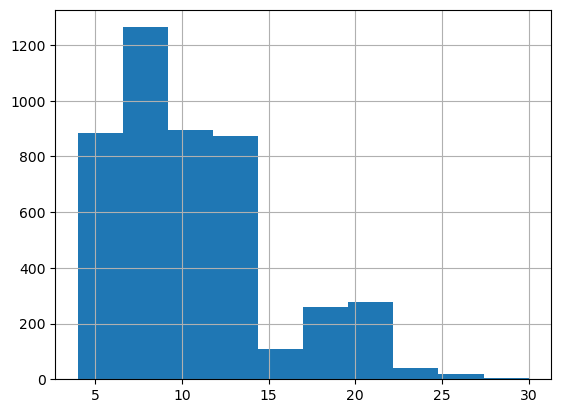

In [711]:
civil_summons_2021['yrs_of_service'].hist()

In [712]:
civil_summons_2021['yrs_of_service'].describe()

count       4630.0
mean     10.638661
std       4.591276
min            4.0
25%            7.0
50%           10.0
75%           13.0
max           30.0
Name: yrs_of_service, dtype: Float64

In [713]:
civil_summons_2021['Reg.hours'].describe()

count    4630.000000
mean     2003.587790
std       304.457743
min         0.000000
25%      2080.000000
50%      2080.000000
75%      2080.000000
max      2172.920000
Name: Reg.hours, dtype: float64

In [714]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Complaintants_First_Name',
 'Complaintants_Last_Name',
 'Tax_Registry_Number_Tax_ID',
 'Agency',
 'Confidence_on_PO_Name',
 'Confidence_on_Officer_Tax_ID',
 'Alternative_Officer_First_Name',
 'Alternative_Officer_Last_Name',
 'Alternative_Officer_Tax_ID',
 'Verified_Name_w_Tax_ID',
 'Last_Name_First_Name',
 'If_Partial_Illegible_ID',
 'Final_Officer_First_Name',
 'Final_Officer_Last_Name',
 'Final_Officer_Tax_ID',
 'Computer_Generated_YN',
 'If_Computer_Generated',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_

<Axes: >

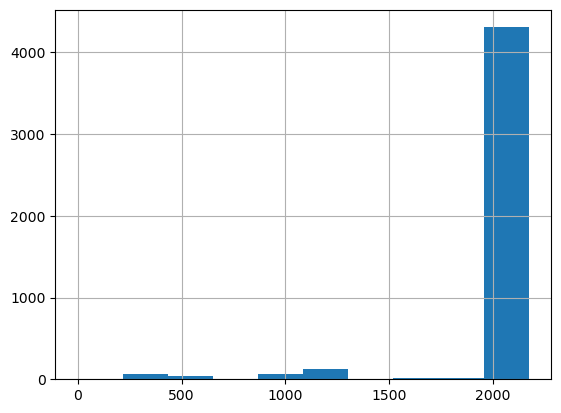

In [715]:
civil_summons_2021['Reg.hours'].hist()

<Axes: >

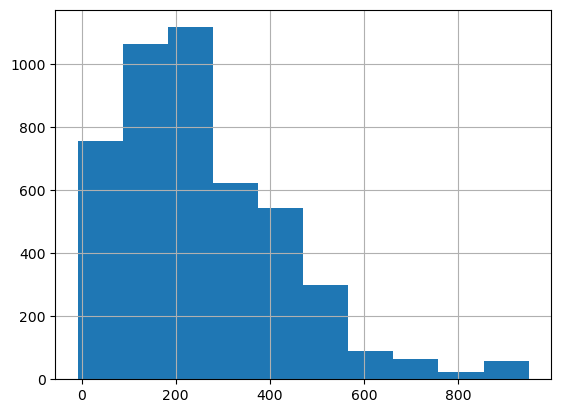

In [716]:
civil_summons_2021['Overtime.hours'].hist()

#### Manually associate Tax IDs for Unusual Names 
- Payroll names do not match  Roster names. This does not indicate that these officers are not found, they just have differnt associated names across these two databases. However, we can still attach a Tax ID to these names by looking at:
  - Roster AKA names (usually contains married changed names)
  - Shield number associated to Tax Number that indicate Start.date (https://nypdonline.org/link/officer-profile)
- IDs that are attachead to a name, but the name is not found in the 2021 payroll all (but 1) are found to be last active before or during 2021. This indicated that the officer either resigned or was relieved of duty during the year 2021 , thus not having logged payroll information for the entire FY.
  - Only ID found in civil_summons_2021 that name was not found in 2021 payroll AND was last active AFTER 2021 was **CLAUDIA S FORREST (#965898)**
- Other IDs found in our civil_summons_2021, but were not associated with a name in the 2021 payroll, were laTst active before 2021. this raises a question of how they were able to give a summons in 2021 if they were relieved/left years before. 

LOGIC - 
from missing_id_list, if there is no initial in Middle.init, all any of the Officer.first.name and Officer.last.name 
of missing_id_list to 
First.name and Last.name of Payroll and connect the Final_Officer_Tax_ID associated from civil_summons

let me know how many merged and how many attached officer IDs

reattache these 

1. if missing_id_list Officer.first.name AND Officer.last.name == payroll_with_ids First.name AND Last.name,
ADD Final_Officer_Tax_ID from missing_id_list to Final_Officer_Tax_ID in payroll_with_ids 
    2. 2261 is the base rn in payroll_with_ids.Final_Officer_Tax_ID we want 2423
2. if missing_id_list 2



#### Completed Training : Consolidated column that contains a list of trainings that a PO completed from a selected group of training categories
**DELETE** 
#### Training Count : Total trainings completed by the PO from a selected group of training categories

**KEEP** 

ANALYSIS: Changed to training_count

In [720]:
civil_summons_2021['Completed Training Names'].value_counts()

Completed Training Names
.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [721]:
# 308 officers have no training 
civil_summons_2021["Training Count"].value_counts().sort_index()

Training Count
.        308
100.0      8
101.0      9
102.0      9
103.0     12
        ... 
95.0      33
96.0      22
97.0      44
98.0      13
99.0      23
Name: count, Length: 178, dtype: int64

In [722]:
# Change name 
civil_summons_2021 = civil_summons_2021.rename(
    columns={"Training Count": "training_count"}
)

In [723]:
civil_summons_2021.training_count.head()

0     58.0
1    165.0
2    150.0
3     96.0
4     94.0
Name: training_count, dtype: object

### After EDA, necessary indicators for analysis: 
- Keep necessary civil_summons_2021 variables for analysis (enforcement)
    - Ticket_Number 
    - Final_Officer_First_Name 
    - Final_Officer_Last_Name
    - Final_Officer_Tax_ID  

- Keep necessary OATH variables for analysis (enforcement)
    - O_Violation_Date
    - month_issued
    - O_Violation_Time
    - O_Violation_Location_Borough
    - O_Respondent_Address_Borough
    - O_Hearing_Status
    - O_Total_Violation_Amount
    - O_Payment_Status
    - O_Compliance_Status
    - O_Final_Charge

- Keep necessary disciplinary actions (DA/CC) variables (behavior) **Think about including later**
    - DA_charge
    - DA_disposition
    - DA_penalty

- Keep necessary arrest count (aa) variables (behavior)
    - aa_felony_arrest_count
    - aa_infraction_arrest_count
    - aa_misdemeanor_arrest_count
    - aa_other_arrest_count
    - aa_violation_arrest_count
    - total_arrest (still has 35 missing/not most updated) 

- Keep necessary award count (aa) variables (behavior)
    - commendation_award_count,
    - excellent_award_count
    - meritorious_award_count
    - meritorious_integrity_award_count
    - exceptional_merit_award_count
    - total_award_count

- Keep most updated rank, command, race, and gender (demographics)
    - roster_rank
    - roster_command
    - roster_race
    - roster_gender

- Keep training_count (behavior)

In [725]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Complaintants_First_Name',
 'Complaintants_Last_Name',
 'Tax_Registry_Number_Tax_ID',
 'Agency',
 'Confidence_on_PO_Name',
 'Confidence_on_Officer_Tax_ID',
 'Alternative_Officer_First_Name',
 'Alternative_Officer_Last_Name',
 'Alternative_Officer_Tax_ID',
 'Verified_Name_w_Tax_ID',
 'Last_Name_First_Name',
 'If_Partial_Illegible_ID',
 'Final_Officer_First_Name',
 'Final_Officer_Last_Name',
 'Final_Officer_Tax_ID',
 'Computer_Generated_YN',
 'If_Computer_Generated',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_

In [726]:
civil_summons_2021.notna().sum()

Ticket_Number                 4663
Complaintants_First_Name      4663
Complaintants_Last_Name       4663
Tax_Registry_Number_Tax_ID    4663
Agency                        4663
                              ... 
Start.date                    4630
pr_first                      4630
pr_last                       4630
pr_middle                     3408
yrs_of_service                4630
Length: 132, dtype: int64

In [727]:
keep_cols = [

    # Officer identifiers
    "Ticket_Number",
    "Final_Officer_Tax_ID",
    "Officer.first.name",
    "Officer.last.name",
    'cs_first',
    'cs_last',
    'cs_middle',
    'pr_first',
    'pr_last',
    'pr_middle',
    # OATH enforcement variables
    'O_Violation_Date',
    'month_issued',
    'O_Violation_Time',
    'O_Issuing_Agency',
    'O_Respondent_first_name',
    'O_Respondent_last_name',
    'O_Balance_Due',
    'O_Violation_Location_Borough',
    'O_Violation_Location_City',
    'O_Violation_Location_Zip_Code',
    'O_Violation_Location_State_Name',
    'O_Respondent_Address_Borough',
    'O_Hearing_Status',
    'O_Hearing_Result',
    'O_Scheduled_Hearing_Location',
    'O_Hearing_Date',
    'O_Hearing_Time',
    'O_Decision_Location_Borough',
    'O_Decision_Date',
    'O_Total_Violation_Amount',
    'O_Violation_Details',
    'O_Date_Judgment_Docketed',
    'O_Penalty_Imposed',
    'O_Paid_Amount',
    'O_Add_Penalties_Late_Fees',
    'O_Compliance_Status',
   
    # Disciplinary actions (keep optional)
    "DA_charge",
    "DA_disposition",
    "DA_penalty",
    
    # Arrest counts
    "aa_felony_arrest_count",
    "aa_infraction_arrest_count",
    "aa_misdemeanor_arrest_count",
    "aa_other_arrest_count",
    "aa_violation_arrest_count",
    "aa_total_arrests",

    # Award counts
    "commendation_award_count",
    "excellent_award_count",
    "meritorious_award_count",
    "meritorious_integrity_award_count",
    "exceptional_merit_award_count",
    "total_award_count",
    
    # Roster demographic data
    "roster_rank",
    "roster_command",
    "roster_race",
    "roster_gender",
    'Total.CCRB.complaints',
    'Total.substantiated.CCRB.complaints',
    'Last.active',

    # Training
    "training_count",
    
   # Payroll
    'yrs_of_service', 
    'Reg.hours',
    'Overtime.hours'
   
]

civil_summons_2021 = civil_summons_2021[keep_cols].copy()


In [728]:
civil_summons_2021 = civil_summons_2021.rename(
    columns={"Training Count": "training_count"}
)

In [729]:

civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'DA_charge',
 'DA_disposition',
 'DA_penalty',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_viola

## Civilian Complaint Review Board EDA
- **Source**: Civilian Complaint Review Board records, as available at NYC OpenData.This table is updated weekly, but the CCRB website will always have the most up-to-date information. Available CCRB reports are linked under “Reports” as they become available to Legal Aid Society. We currently have detailed reports for 6697 cases.
- **Description**: This table is updated weekly, but the CCRB website will always have the most up-to-date information. Available CCRB reports are linked under “Reports” as they become available to Legal Aid Society. We currently have detailed reports for 6697 cases. Reports are produced to Legal Aid Society as responses to FOIL requests by CAP, or obtained through other advocacy organizations like LatinoJustice and 50-a.org, and or when released by media outlets. Multiple versions of the same or similar reports may be available in some cases.
- **Scope**: 2021 - Present 
- **Key Variables:**
    - Complaint.category (FADO)
    - CCRB.complaint.disposition
    - Borough.of.incident
    - Victim.race.ethnicity.at.incident..legacy.
    - Victim.gender.at.incident
    - investigator_recommendation

**ANALYSIS: Out of our 2423 unique officers, 1252 officers have CCRB Allegations = 6255 allegations total** 

In [731]:
# Create a list of the Tax IDs you want to filter by
tax_ids = civil_summons_2021["Final_Officer_Tax_ID"].dropna().unique().tolist()

ccrb_2021 = pd.read_csv(
    "data/ccrb_2021_present.tsv",
    sep="\t",
    dtype=str
)

ccrb_2021['Tax..'] = pd.to_numeric(
    ccrb_2021['Tax..'],
    errors='coerce'
)

# Filter rows where Tax_Registry_Number_Tax_ID matches
ccrb_filtered = ccrb_2021[ccrb_2021["Tax.."].isin(tax_ids)].copy()

In [732]:
len(tax_ids)

2423

In [733]:
ccrb_2021

,Tax..,Officer.last.name,Officer.first.name,Current.command,Current.rank,Current.shield,Complaint.ID,Report,Complaint.date,Incident.date,...,Close.date,Borough.of.incident,Precinct.of.incident,Location.of.incident,Reason.for.police.contact,Outcome.of.police.encounter,APU.close.date,bwc_evidence,video_evidence,investigator_recommendation
0,874365.0,Hughes,Stephen,828,2,00000,202102650,<a href='https://s3.documentcloud.org/document...,18746,18412,...,19975,3,5,15,NaN,NaN,NaN,Yes,Yes,Substantiated
1,874365.0,Hughes,Stephen,828,2,00000,202107262,<a href='https://s3.documentcloud.org/document...,18961,18471,...,19130,3,26,7,17,5,NaN,Yes,Yes,Exonerated
2,875334.0,Evans,Daniel,334,9,01768,202101967,NaN,18712,18711,...,19184,1,48,15,34,9,NaN,No,Yes,Miscellaneous - Subject Retired
3,875334.0,Evans,Daniel,334,9,01768,202101967,NaN,18712,18711,...,19184,1,48,15,34,9,NaN,No,Yes,Miscellaneous - Subject Retired
4,875334.0,Evans,Daniel,334,9,01768,202101967,NaN,18712,18711,...,19184,1,48,15,34,9,NaN,No,Yes,Miscellaneous - Subject Retired
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72302,NaN,NaN,NaN,NaN,NaN,NaN,9002067,<a href='https://s3.documentcloud.org/document...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72303,NaN,NaN,NaN,NaN,NaN,NaN,9904509,<a href='https://s3.documentcloud.org/document...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72304,NaN,NaN,NaN,NaN,NaN,NaN,9401480,<a href='https://s3.documentcloud.org/document...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
72305,NaN,NaN,NaN,NaN,NaN,NaN,9903600,<a href='https://s3.documentcloud.org/document...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [734]:
len(ccrb_filtered)

6255

In [735]:
# Out of our 2423 unique officers, 1252 officers have CCRB Allegations = 6255 allegations total 
ccrb_filtered.describe()

,Tax..
count,6255.000000
mean,962328.556355
std,8230.092512
min,916969.000000
25%,959978.000000
50%,964971.000000
75%,967499.000000
max,971756.000000


In [736]:
ccrb_filtered.columns.to_list()

['Tax..',
 'Officer.last.name',
 'Officer.first.name',
 'Current.command',
 'Current.rank',
 'Current.shield',
 'Complaint.ID',
 'Report',
 'Complaint.date',
 'Incident.date',
 'Incident.hour',
 'Allegation.ID',
 'Complaint.category',
 'Allegation',
 'CCRB.complaint.disposition',
 'CCRB.allegation.disposition',
 'NYPD.allegation.disposition',
 'CCRB.disposition.of.substantiated.charges',
 'CCRB.discipline.recommendation',
 'NYPD.Penalty',
 'NYPD.penalty.date',
 'APU.case',
 'APU.case.status',
 'APU.Plea.agreed.penalty',
 'APU.CCRB.Trial.recommended.penalty',
 'APU.Trial.Commissioner.Recommended.Penalty',
 'Complaint.officer.number',
 'Rank.at.incident',
 'Command.at.incident',
 'Days.on.force.at.incident',
 'Victim.age.at.incident',
 'Victim.gender.at.incident',
 'Victim.race.ethnicity.at.incident..legacy.',
 'Victim.race.ethnicity.at.incident',
 'Close.date',
 'Borough.of.incident',
 'Precinct.of.incident',
 'Location.of.incident',
 'Reason.for.police.contact',
 'Outcome.of.police.enc

In [737]:
ccrb_filtered["Allegation.ID"].nunique()

6255

In [738]:
allegation_counts = ccrb_filtered['Tax..'].value_counts()
print(allegation_counts)

Tax..
965915.0    72
967022.0    68
967409.0    64
969890.0    55
964719.0    55
            ..
966887.0     1
960950.0     1
966858.0     1
966838.0     1
967451.0     1
Name: count, Length: 1253, dtype: int64


In [739]:
# Key behavioral variables that we want from CCRB data connected to our officers
key_variables = [
    "Tax..",
    "Complaint.category",
    "CCRB.allegation.disposition",
    "Borough.of.incident",
    "Victim.race.ethnicity.at.incident..legacy.",
    "Victim.gender.at.incident",
    "investigator_recommendation"
]

# Keep only those columns
ccrb_filtered = ccrb_filtered[key_variables]

In [740]:
ccrb_filtered.head(20)

,Tax..,Complaint.category,CCRB.allegation.disposition,Borough.of.incident,Victim.race.ethnicity.at.incident..legacy.,Victim.gender.at.incident,investigator_recommendation
318,916969.0,2,24,2,4,1,Unsubstantiated
319,916969.0,4,24,2,4,1,Unsubstantiated
320,916969.0,3,26,2,3,2,Exonerated
321,916969.0,1,15,2,3,2,Substantiated
322,916969.0,4,22,2,3,2,Unable to Determine
323,916969.0,2,22,2,3,2,Unable to Determine
324,916969.0,1,5,2,NaN,2,Complainant Uncooperative
325,916969.0,1,26,2,NaN,NaN,Within NYPD Guidelines
326,916969.0,3,6,2,NaN,2,Complaint Withdrawn
327,916969.0,3,6,2,NaN,2,Complaint Withdrawn


#### Complaint.category: 
  - Abuse of Authority: Refers to abuse of police powers to intimidate or mistreat a civilian; for example, an officer’s refusal to provide name and badge number, or an improper “stop, question and frisk.” 
  - Discourtesy: Refers to cursing and using other foul language or gestures.
  - Force: Refers to the use of excessive or unnecessary force; behavior that includes punching or shoving and up to and including the use of deadly force. 
  - Offensive Language: Refers to slurs and derogatory remarks or gestures based upon race, ethnicity, religion, gender, sexual orientation, or physical disability.
  - Untruthful Statement
  
index:
  - 1
  - 2
  - 3
  - 4
  - 5

In [742]:
ccrb_filtered['Complaint.category'].value_counts()

Complaint.category
1    3785
3    1754
2     580
4     122
5      14
Name: count, dtype: int64

<Axes: xlabel='Complaint.category'>

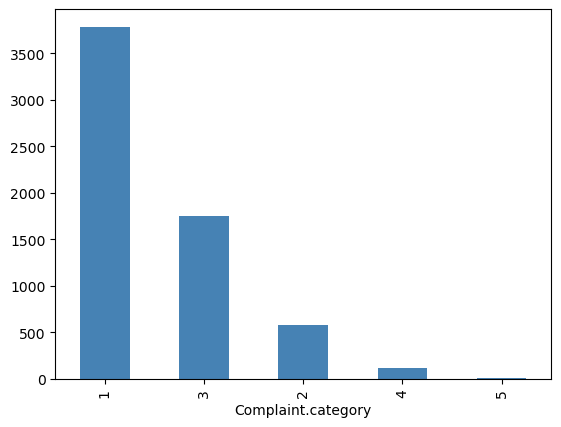

In [743]:
ccrb_filtered['Complaint.category'].value_counts().plot(kind="bar", color="steelblue")

In [744]:
ccrb_filtered['Complaint.category'].unique()

array(['2', '4', '3', '1', '5'], dtype=object)

In [745]:

ccrb_filtered['Complaint.category'] = (
    ccrb_filtered['Complaint.category']
    .astype(str)              # ensure string
    .str.strip()              # remove whitespace
    .astype(int)              # convert to integer
)

category_map = {
    1: "Abuse of Authority",
    2: "Discourtesy",
    3: "Force",
    4: "Offensive Language",
    5: "Untruthful Statement"
}

ccrb_filtered['Complaint.category'] = (
    ccrb_filtered['Complaint.category']
    .map(category_map)
)

ccrb_filtered['Complaint.category'].value_counts()


Complaint.category
Abuse of Authority      3785
Force                   1754
Discourtesy              580
Offensive Language       122
Untruthful Statement      14
Name: count, dtype: int64

#### CCRB.allegation.disposition: Bin into 5 categories (Substantiated, Unable to Determine, Unfounded, Within NYPD Guidelines, Officers Unidentified): 

  - 1. Alleged Victim Unavailable 
  - 2. Alleged Victim Uncooperative
  - 3. Closed - Pending Litigation
  - 4. Complainant Unavailable
  - 5. Complainant Uncooperative
  - 6. Complaint Withdrawn
  - 7. Exonerated
  - 8. Miscellaneous
  - 30. Miscellaneous - Subject Deceased
  - 9. Miscellaneous - Subject Resigned
  - 10. Miscellaneous - Subject Retired
  - 11. Miscellaneous - Subject Terminated
  - 12. Officer(s) Unidentified
  - 13. OMB PEG Directive Closure
  - 29. SRAD Closure
  - 14. Substantiated (Charges)
  - 15. Substantiated (Command Discipline A)
  - 16. Substantiated (Command Discipline B)
  - 17. Substantiated (Command Discipline)
  - 18. Substantiated (Command Lvl Instructions)
  - 19. Substantiated (Formalized Training)
  - 20. Substantiated (Instructions)
  - 21. Substantiated (No Recommendations)
  - 22. Unable to Determine
  - 23. Unfounded
  - 24. Unsubstantiated
  - 25. Victim Unidentified
  - 26. Within NYPD Guidelines
  - 27. Witness Unavailable
  - 28. Witness Uncooperative
  


In [747]:
disposition_bin = {
    # SUBSTANTIATED
    14: "SUBSTANTIATED",
    15: "SUBSTANTIATED",
    16: "SUBSTANTIATED",
    17: "SUBSTANTIATED",
    18: "SUBSTANTIATED",
    19: "SUBSTANTIATED",
    20: "SUBSTANTIATED",
    21: "SUBSTANTIATED",

    # also treat "mediated" as legit complaint
    9: "SUBSTANTIATED",   # if mediation attempted appears later
    32: "SUBSTANTIATED",  # if your dataset includes "Mediated"

    # UNABLE TO DETERMINE
    22: "UNABLE TO DETERMINE",

    # UNFOUNDED (and complainant not available)
    23: "UNFOUNDED",
    1: "UNFOUNDED",
    2: "UNFOUNDED",
    3: "UNFOUNDED",
    4: "UNFOUNDED",
    5: "UNFOUNDED",
    6: "UNFOUNDED",
    25: "UNFOUNDED",
    27: "UNFOUNDED",
    28: "UNFOUNDED",

    # WITHIN GUIDELINES (exonerated + administrative)
    26: "WITHIN GUIDELINES",
    7: "WITHIN GUIDELINES",
    8: "WITHIN GUIDELINES",
    9: "WITHIN GUIDELINES",
    10: "WITHIN GUIDELINES",
    11: "WITHIN GUIDELINES",
    13: "WITHIN GUIDELINES",
    29: "WITHIN GUIDELINES",
    30: "WITHIN GUIDELINES",

    # OFFICER UNIDENTIFIED
    12: "OFFICER UNIDENTIFIED"
}


ccrb_filtered["disposition_bin"] = (
    ccrb_filtered["CCRB.allegation.disposition"]
    .astype(int)
    .map(disposition_bin)
    .fillna("OTHER")
)

In [748]:
ccrb_filtered["disposition_bin"].value_counts()

disposition_bin
UNFOUNDED              2244
WITHIN GUIDELINES      2124
SUBSTANTIATED          1023
UNABLE TO DETERMINE     736
OTHER                   128
Name: count, dtype: int64

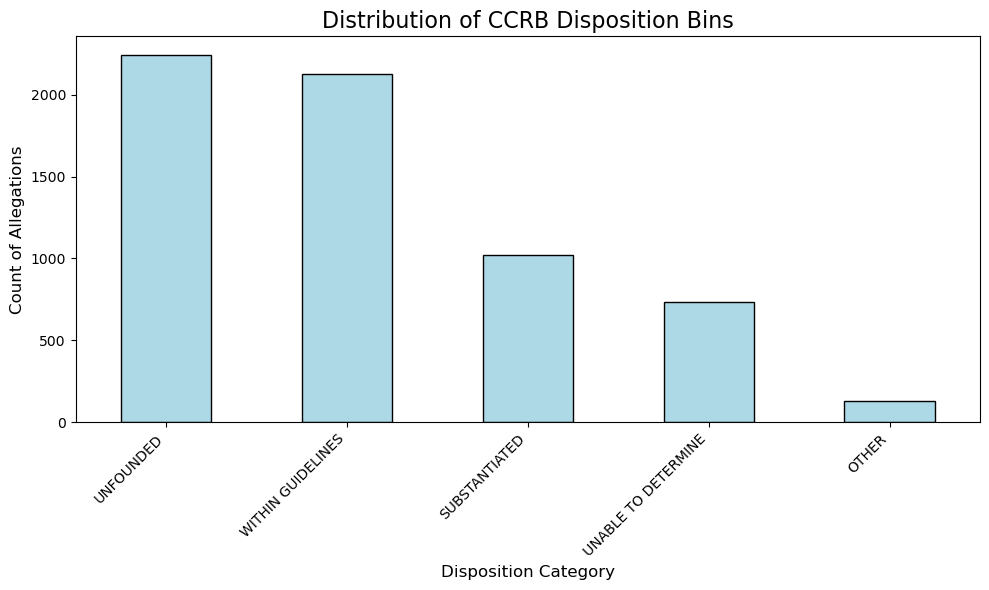

In [749]:
plt.figure(figsize=(10,6))

ccrb_filtered["disposition_bin"].value_counts().plot(
    kind="bar",
    edgecolor="black",
    color="lightblue"                               
)

plt.title("Distribution of CCRB Disposition Bins", fontsize=16)
plt.xlabel("Disposition Category", fontsize=12)
plt.ylabel("Count of Allegations", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()


plt.savefig('EDA_figures/Distribution of CCRB Disposition Bins.png', dpi=300, bbox_inches='tight')
plt.show()

In [750]:
ccrb_filtered['CCRB.allegation.disposition'].value_counts()

CCRB.allegation.disposition
26    1539
23     896
22     736
15     655
3      417
5      336
4      315
7      277
6      173
19     130
24     128
16     124
14     114
13     104
9       82
29      71
1       48
10      40
2       39
25      20
11       7
8        4
Name: count, dtype: int64

#### Borough.of.incident: shows where the complaints happened 
  - Bronx
  - Brooklyn
  - Manhattan
  - Outside NYC
  - Queens
  - Staten Island

index:
  - 1
  - 2
  - 3
  - 4
  - 5
  - 6

In [752]:
ccrb_filtered['Borough.of.incident'].value_counts()

Borough.of.incident
2    2237
3    1542
5    1156
1    1147
6     151
Name: count, dtype: int64

<Axes: xlabel='Borough.of.incident'>

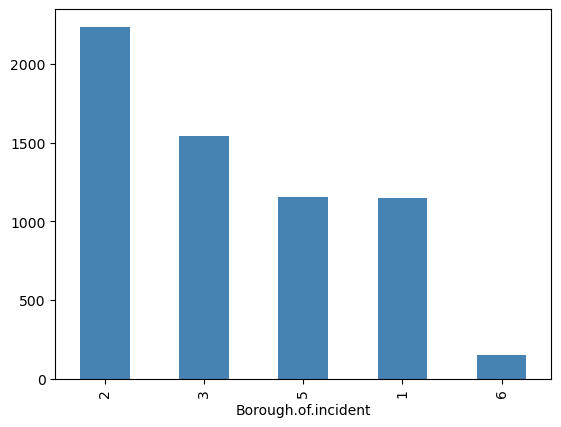

In [753]:
ccrb_filtered['Borough.of.incident'].value_counts().plot(kind="bar", color="steelblue")

In [754]:

borough_map = {
    "1": "Bronx",
    "2": "Brooklyn",
    "3": "Manhattan",
    "5": "Queens",
    "6": "Staten Island"
}


ccrb_filtered['Borough.of.incident'] = (
    ccrb_filtered['Borough.of.incident']
    .map(borough_map)
)

ccrb_filtered['Borough.of.incident'].value_counts()

Borough.of.incident
Brooklyn         2237
Manhattan        1542
Queens           1156
Bronx            1147
Staten Island     151
Name: count, dtype: int64

In [755]:
ccrb_filtered['Borough.of.incident'].value_counts()

Borough.of.incident
Brooklyn         2237
Manhattan        1542
Queens           1156
Bronx            1147
Staten Island     151
Name: count, dtype: int64

#### Victim.race.ethnicity.at.incident..legacy.: 
  - American Indian
  - Asian
  - Black
  - Hispanic
  - Other Race
  - Refused
  - Unknown
  - White
  
  
  index:
  - 1
  - 2
  - 3
  - 4
  - 5
  - 6
  - 7
  - 8

In [757]:
ccrb_filtered['Victim.race.ethnicity.at.incident..legacy.'].value_counts()

Victim.race.ethnicity.at.incident..legacy.
3    930
4    352
8    330
7    263
5    118
2    107
1     24
6     18
Name: count, dtype: int64

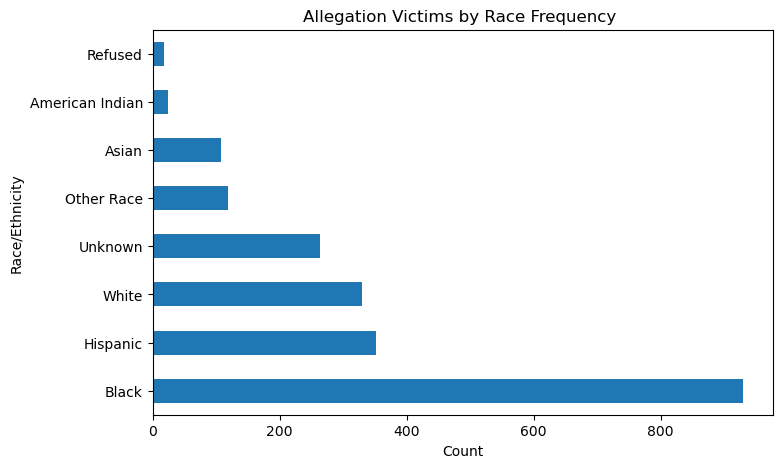

In [758]:
# Plotting allegations victims by Race 
race_map = {
    1: "American Indian",
    2: "Asian",
    3: "Black",
    4: "Hispanic",
    5: "Other Race",
    6: "Refused",
    7: "Unknown",
    8: "White"
}

gender_map = {
    1: "Female", 
    2: "Male", 
    3: "TGNC"
}

# plot 
(
    ccrb_filtered["Victim.race.ethnicity.at.incident..legacy."] 
    .astype(float) 
    .map(race_map)
    .value_counts()
    .plot(kind="barh", title="Allegation Victims by Race Frequency ", figsize=(8,5))
)

plt.xlabel("Count")
plt.ylabel("Race/Ethnicity")

plt.savefig('EDA_figures/Allegation Victims by Race Frequency.png', dpi=300, bbox_inches='tight')
plt.show()

#### Victim.gender.at.incident: 
  - Female/Woman
  - Male/Man
  - TGNC / Other

index:
  - 1
  - 2
  - 3

In [760]:
ccrb_filtered['Victim.gender.at.incident'].value_counts()

Victim.gender.at.incident
2    4112
1    1325
3      51
Name: count, dtype: int64

<Axes: xlabel='Victim.gender.at.incident'>

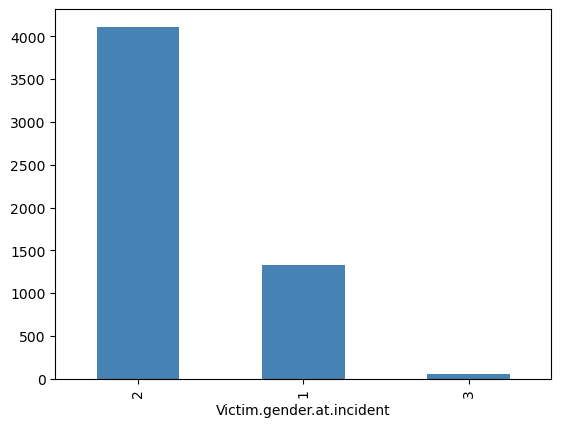

In [761]:
ccrb_filtered['Victim.gender.at.incident'].value_counts().plot(kind="bar", color="steelblue")

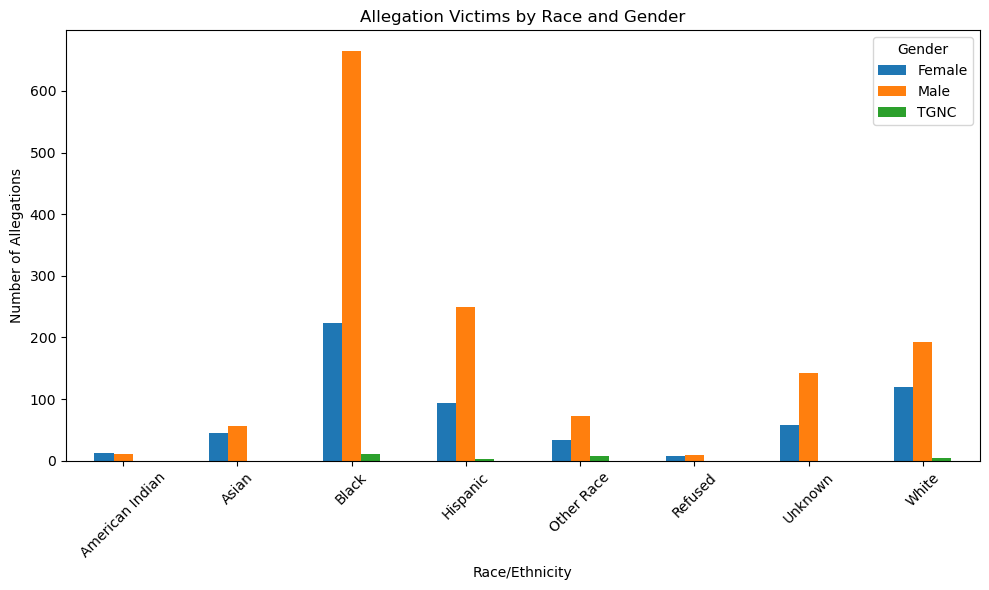

In [762]:
# Plotting victims by Race and Gender 
gender_map = {
    1: "Female", 
    2: "Male", 
    3: "TGNC" #transgender/non-conforming
}

# apply mappings
ccrb_filtered["Race"] = (
    ccrb_filtered["Victim.race.ethnicity.at.incident..legacy."]
    .astype(float)
    .map(race_map)
)

ccrb_filtered["Gender"] = (
    ccrb_filtered["Victim.gender.at.incident"]
    .astype(float)
    .map(gender_map)
)

# create a cross-tab (Race × Gender counts)
race_gender_counts = pd.crosstab(ccrb_filtered["Race"], ccrb_filtered["Gender"])

race_gender_counts.plot(
    kind="bar",
    figsize=(10,6),
    title="Allegation Victims by Race and Gender"
)

plt.xlabel("Race/Ethnicity")
plt.ylabel("Number of Allegations")
plt.xticks(rotation=45)
plt.legend(title="Gender")

plt.tight_layout()  # makes sure labels/titles aren’t cut off
plt.savefig('EDA_figures/Allegation Victims by Race and Gender.png', dpi=300, bbox_inches='tight')
plt.show()

#### Investigator Recommendation is the actual response to CCRB allegations 

<Axes: xlabel='investigator_recommendation'>

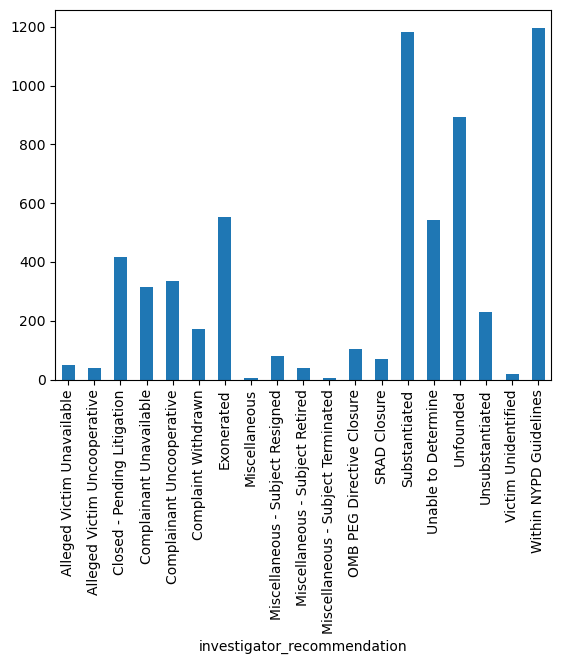

In [764]:
# Investigator Recommendation is the actuar response of the CCRB allegation 
ccrb_filtered["investigator_recommendation"].value_counts().sort_index().plot(kind="bar")

In [765]:
ccrb_filtered["investigator_recommendation"].value_counts()

investigator_recommendation
Within NYPD Guidelines                1197
Substantiated                         1183
Unfounded                              894
Exonerated                             553
Unable to Determine                    543
Closed - Pending Litigation            417
Complainant Uncooperative              336
Complainant Unavailable                315
Unsubstantiated                        231
Complaint Withdrawn                    173
OMB PEG Directive Closure              104
Miscellaneous - Subject Resigned        80
SRAD Closure                            71
Alleged Victim Unavailable              48
Miscellaneous - Subject Retired         40
Alleged Victim Uncooperative            39
Victim Unidentified                     20
Miscellaneous - Subject Terminated       7
Miscellaneous                            4
Name: count, dtype: int64

#### Merging CCRB behavior data with original civil_summons_2021
- Renaming ccrb_filtered tax.. to Final_Officer_Tax_ID
- Merge on Final_Officer_Tax_ID

In [767]:
ccrb_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6255 entries, 318 to 46969
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Tax..                                       6255 non-null   float64
 1   Complaint.category                          6255 non-null   object 
 2   CCRB.allegation.disposition                 6255 non-null   object 
 3   Borough.of.incident                         6233 non-null   object 
 4   Victim.race.ethnicity.at.incident..legacy.  2142 non-null   object 
 5   Victim.gender.at.incident                   5488 non-null   object 
 6   investigator_recommendation                 6255 non-null   object 
 7   disposition_bin                             6255 non-null   object 
 8   Race                                        2142 non-null   object 
 9   Gender                                      5488 non-null   object 
dtypes: float64(1),

In [768]:
ccrb_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6255 entries, 318 to 46969
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Tax..                                       6255 non-null   float64
 1   Complaint.category                          6255 non-null   object 
 2   CCRB.allegation.disposition                 6255 non-null   object 
 3   Borough.of.incident                         6233 non-null   object 
 4   Victim.race.ethnicity.at.incident..legacy.  2142 non-null   object 
 5   Victim.gender.at.incident                   5488 non-null   object 
 6   investigator_recommendation                 6255 non-null   object 
 7   disposition_bin                             6255 non-null   object 
 8   Race                                        2142 non-null   object 
 9   Gender                                      5488 non-null   object 
dtypes: float64(1),

In [769]:
civil_summons_2021.head(15)

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_last,cs_middle,pr_first,pr_last,pr_middle,...,roster_command,roster_race,roster_gender,Total.CCRB.complaints,Total.substantiated.CCRB.complaints,Last.active,training_count,yrs_of_service,Reg.hours,Overtime.hours
0,190851430,953430,NICHOLAS,SORECA,NICHOLAS,SORECA,V,NICHOLAS,SORECA,V,...,48,6,2,1,1,20301,58.0,13,2080.0,100.95
1,196184708,961743,PATRICIA,ENNIS,PATRICIA,ENNIS,NAN,PATRICIA,ENNIS,NaN,...,80,6,1,4,0,20301,165.0,9,2080.0,256.83
2,196241834,961465,JAMES,WYNNE,JAMES,WYNNE,W,JAMES,WYNNE,W,...,116,6,2,2,0,20301,150.0,10,2080.0,182.67
3,196242292,964085,MICHAEL,KENJESKY,MICHAEL,KENJESKY,V,MICHAEL,KENJESKY,V,...,116,6,2,1,0,20301,96.0,8,2080.0,46.42
4,196244840,964778,MICHAEL,SINTO,MICHAEL,SINTO,G,MICHAEL,SINTO,G,...,89,6,2,2,1,20301,94.0,8,2080.0,379.42
5,196264925,963591,ERIN,KENNEDY,ERIN,KENNEDY,L,ERIN,KENNEDY,L,...,125,6,1,1,0,20059,69.0,8,2080.0,229.33
6,196269581,963656,MARISSA,DINIS,MARISSA,DINIS,L,MARISSA,MONACO,L,...,125,6,1,0,0,20301,74.0,8,2080.0,195.33
7,196320722,952904,FREDDY,JONES,FREDDY,JONES,NAN,FREDDY,JONES,NaN,...,158,3,2,0,0,19236,44.0,13,2080.0,260.08
8,196374613,966902,ANTHONY,VELAZQUEZ,ANTHONY,VELAZQUEZ,F,ANTHONY,VELAZQUEZ,F,...,1057,4,2,1,0,20301,40.0,7,2080.0,377.92
9,196380892,966375,JOSEPH,VADALA,JOSEPH,VADALA,NAN,JOSEPH,VADALA,G,...,131,6,2,0,0,18779,.,7,2068.6,62.33


In [770]:
# Lets get total_allegation 
allegation_counts

ccrb_filtered['Tax..'] = (
    pd.to_numeric(ccrb_filtered['Tax..'], errors='coerce')
    .astype('Int64')
)

civil_summons_2021['Final_Officer_Tax_ID'] = (
    pd.to_numeric(civil_summons_2021['Final_Officer_Tax_ID'], errors='coerce')
    .astype('Int64')
)

In [771]:
allegation_counts

Tax..
965915.0    72
967022.0    68
967409.0    64
969890.0    55
964719.0    55
            ..
966887.0     1
960950.0     1
966858.0     1
966838.0     1
967451.0     1
Name: count, Length: 1253, dtype: int64

In [772]:
civil_summons_2021['Final_Officer_Tax_ID']

0       953430
1       961743
2       961465
3       964085
4       964778
         ...  
4658    952535
4659    953330
4660    948461
4661    948461
4662    954342
Name: Final_Officer_Tax_ID, Length: 4663, dtype: Int64

In [773]:
civil_summons_2021['CCRB_Total_Allegations'] = (
    civil_summons_2021['Final_Officer_Tax_ID']
    .map(allegation_counts)
    .fillna(0)
    .astype(int)
)

In [774]:
civil_summons_2021.CCRB_Total_Allegations.value_counts()

CCRB_Total_Allegations
0     2125
1      759
2      380
3      362
4      298
5      139
6       96
7       84
8       74
11      73
12      52
9       48
15      24
13      21
10      19
18      18
19      15
17      12
14      11
20       9
16       5
27       5
21       4
55       3
33       3
22       3
52       3
46       2
24       2
36       2
38       2
49       1
42       1
68       1
25       1
23       1
37       1
28       1
50       1
72       1
64       1
Name: count, dtype: int64

In [775]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'DA_charge',
 'DA_disposition',
 'DA_penalty',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_viola

In [776]:
civil_summons_2021.to_csv("data/civil_summons_2021_v1.csv")

In [777]:
# Sum Officer Total Summonses
civil_summons_2021['Officer_Total_Summonses'] = (
    civil_summons_2021
        .groupby('Final_Officer_Tax_ID')['Ticket_Number']
        .transform('count')
)

In [778]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'DA_charge',
 'DA_disposition',
 'DA_penalty',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_viola

In [779]:
ccrb_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6255 entries, 318 to 46969
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Tax..                                       6255 non-null   Int64 
 1   Complaint.category                          6255 non-null   object
 2   CCRB.allegation.disposition                 6255 non-null   object
 3   Borough.of.incident                         6233 non-null   object
 4   Victim.race.ethnicity.at.incident..legacy.  2142 non-null   object
 5   Victim.gender.at.incident                   5488 non-null   object
 6   investigator_recommendation                 6255 non-null   object
 7   disposition_bin                             6255 non-null   object
 8   Race                                        2142 non-null   object
 9   Gender                                      5488 non-null   object
dtypes: Int64(1), object(9)
mem

#### ccrb['Victim.race.ethnicity.at.incident..legacy.'].value_counts()

1  - American Indian
2  - Asian
3  - Black
4  - Hispanic
5  - Other Race
6  - Refused
7  - Unknown
8  - White

In [781]:
# 1. Create dummy variables for each victim race category
race_dummies = pd.get_dummies(ccrb_filtered['Race'], prefix='VictimRace')
race_dummies

,VictimRace_American Indian,VictimRace_Asian,VictimRace_Black,VictimRace_Hispanic,VictimRace_Other Race,VictimRace_Refused,VictimRace_Unknown,VictimRace_White
318,False,False,False,True,False,False,False,False
319,False,False,False,True,False,False,False,False
320,False,False,True,False,False,False,False,False
321,False,False,True,False,False,False,False,False
322,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...
46841,False,False,False,False,False,False,False,False
46941,False,False,False,False,False,False,False,False
46967,False,False,False,False,False,False,False,False
46968,False,False,False,False,False,False,False,False


In [782]:
ccrb_with_dummies = pd.concat([ccrb_filtered[['Tax..']], race_dummies], axis=1)
    
# 3. Aggregate counts of each race by officer
ccrb_race_counts = ccrb_with_dummies.groupby('Tax..').sum().reset_index()

# 4. Rename columns to clearer names (optional)
ccrb_race_counts = ccrb_race_counts.rename(columns={
    'Tax..': 'Final_Officer_Tax_ID',
    'VictimRace_Black': 'CCRB_Black_Allegations',
    'VictimRace_White': 'CCRB_White_Allegations',
    'VictimRace_Asian': 'CCRB_Asian_Allegations',
    'VictimRace_Hispanic': 'CCRB_Hispanic_Allegations',
    'VictimRace_Other Race': 'CCRB_Other_Allegations',
    'VictimRace_Refused': 'CCRB_RefusedRace_Allegations',
    'VictimRace_Unknown': 'CCRB_Unknown_Allegations',
    'VictimRace_American Indian': 'CCRB_AmericanIndian_Allegations'
})


In [783]:
civil_summons_2021['Final_Officer_Tax_ID'] = (
    civil_summons_2021['Final_Officer_Tax_ID']
    .astype(str)
    .str.strip()
)

ccrb_race_counts['Final_Officer_Tax_ID'] = (
    ccrb_race_counts['Final_Officer_Tax_ID']
    .astype(str)
    .str.strip()
)


In [784]:
# Merge CCRB and civil summons on Final_Officer_Tax_ID 
civil_summons_2021 = civil_summons_2021.merge(
    ccrb_race_counts,
    on='Final_Officer_Tax_ID',
    how='left'
)

In [785]:
# Save data 
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'DA_charge',
 'DA_disposition',
 'DA_penalty',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_viola

In [786]:
civil_summons_2021.head()

,Ticket_Number,Final_Officer_Tax_ID,Officer.first.name,Officer.last.name,cs_first,cs_last,cs_middle,pr_first,pr_last,pr_middle,...,CCRB_Total_Allegations,Officer_Total_Summonses,CCRB_AmericanIndian_Allegations,CCRB_Asian_Allegations,CCRB_Black_Allegations,CCRB_Hispanic_Allegations,CCRB_Other_Allegations,CCRB_RefusedRace_Allegations,CCRB_Unknown_Allegations,CCRB_White_Allegations
0,190851430,953430,NICHOLAS,SORECA,NICHOLAS,SORECA,V,NICHOLAS,SORECA,V,...,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,196184708,961743,PATRICIA,ENNIS,PATRICIA,ENNIS,NAN,PATRICIA,ENNIS,NaN,...,2,3,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
2,196241834,961465,JAMES,WYNNE,JAMES,WYNNE,W,JAMES,WYNNE,W,...,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,196242292,964085,MICHAEL,KENJESKY,MICHAEL,KENJESKY,V,MICHAEL,KENJESKY,V,...,1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,196244840,964778,MICHAEL,SINTO,MICHAEL,SINTO,G,MICHAEL,SINTO,G,...,4,1,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0


In [787]:
civil_summons_2021.CCRB_Black_Allegations.value_counts()

CCRB_Black_Allegations
0.0     1894
1.0      342
2.0      145
3.0       55
4.0       30
5.0       16
7.0       13
6.0        9
8.0        9
10.0       7
12.0       5
17.0       3
16.0       2
11.0       2
9.0        2
22.0       1
15.0       1
13.0       1
23.0       1
Name: count, dtype: int64

In [788]:
# Map rank, race, and gender 
civil_summons_2021.roster_rank.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4663 entries, 0 to 4662
Series name: roster_rank
Non-Null Count  Dtype 
--------------  ----- 
4663 non-null   object
dtypes: object(1)
memory usage: 36.6+ KB


In [789]:
civil_summons_2021.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 72 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Ticket_Number                        4663 non-null   int64         
 1   Final_Officer_Tax_ID                 4663 non-null   object        
 2   Officer.first.name                   4663 non-null   object        
 3   Officer.last.name                    4663 non-null   object        
 4   cs_first                             4663 non-null   object        
 5   cs_last                              4663 non-null   object        
 6   cs_middle                            4663 non-null   object        
 7   pr_first                             4630 non-null   object        
 8   pr_last                              4630 non-null   object        
 9   pr_middle                            3408 non-null   object        
 10  O_Violation_

In [790]:
civil_summons_2021.select_dtypes('object').nunique()

Final_Officer_Tax_ID                   2423
Officer.first.name                     1077
Officer.last.name                      1867
cs_first                               1077
cs_last                                1867
cs_middle                                27
pr_first                               1069
pr_last                                1869
pr_middle                                26
O_Violation_Time                       1033
O_Issuing_Agency                          2
O_Respondent_first_name                2979
O_Respondent_last_name                 2885
O_Balance_Due                            51
O_Violation_Location_Borough              7
O_Violation_Location_City                37
O_Violation_Location_Zip_Code           157
O_Violation_Location_State_Name           2
O_Respondent_Address_Borough              7
O_Hearing_Status                          8
O_Hearing_Result                          6
O_Scheduled_Hearing_Location             10
O_Hearing_Date                  

In [791]:
civil_summons_2021[['roster_rank','roster_race','roster_gender']].dtypes

roster_rank      object
roster_race      object
roster_gender    object
dtype: object

In [792]:
rank_map = {
    1: "CAPTAIN",
    2: "CHIEFS AND OTHER RANKS",
    3: "DEPUTY INSPECTOR",
    4: "DETECTIVE",
    5: "INACTIVE RANKS",
    6: "INSPECTOR",
    7: "LIEUTENANT",
    8: "POLICE OFFICER",
    9: "SERGEANT"
}

race_map = {
    1: "AMERICAN INDIAN",
    2: "ASIAN",
    3: "BLACK",
    4: "HISPANIC",
    5: "OTHER RACE",
    6: "WHITE"
}

gender_map = {
    1: "FEMALE",
    2: "MALE",
    3: "TGNC / OTHER"
}


<Axes: >

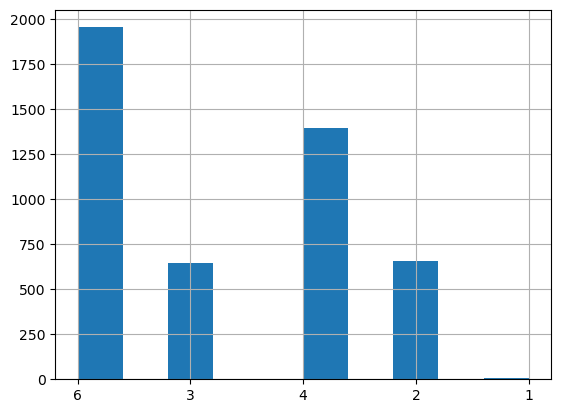

In [793]:
civil_summons_2021.roster_race.hist()

In [794]:
# Convert floats to integers safely (NaN becomes NaN)
civil_summons_2021['roster_rank'] = civil_summons_2021['roster_rank'].astype('Int64')
civil_summons_2021['roster_race'] = civil_summons_2021['roster_race'].astype('Int64')
civil_summons_2021['roster_gender'] = civil_summons_2021['roster_gender'].astype('Int64')

# Map integer codes to text labels
civil_summons_2021['roster_rank'] = civil_summons_2021['roster_rank'].map(rank_map)
civil_summons_2021['roster_race'] = civil_summons_2021['roster_race'].map(race_map)
civil_summons_2021['roster_gender'] = civil_summons_2021['roster_gender'].map(gender_map)


In [795]:
civil_summons_2021[['roster_rank','roster_race','roster_gender']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   roster_rank    4663 non-null   object
 1   roster_race    4663 non-null   object
 2   roster_gender  4662 non-null   object
dtypes: object(3)
memory usage: 109.4+ KB


In [796]:
civil_summons_2021['roster_race'].head()

0    WHITE
1    WHITE
2    WHITE
3    WHITE
4    WHITE
Name: roster_race, dtype: object

In [797]:
# Replace missing values with "UNKNOWN"
civil_summons_2021['roster_rank']   = civil_summons_2021['roster_rank'].fillna("UNKNOWN")
civil_summons_2021['roster_race']   = civil_summons_2021['roster_race'].fillna("UNKNOWN")
civil_summons_2021['roster_gender'] = civil_summons_2021['roster_gender'].fillna("UNKNOWN")


In [798]:
civil_summons_2021[['roster_rank','roster_race','roster_gender']].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4663 entries, 0 to 4662
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   roster_rank    4663 non-null   object
 1   roster_race    4663 non-null   object
 2   roster_gender  4663 non-null   object
dtypes: object(3)
memory usage: 109.4+ KB


In [799]:
civil_summons_2021.select_dtypes('object').nunique()

Final_Officer_Tax_ID                   2423
Officer.first.name                     1077
Officer.last.name                      1867
cs_first                               1077
cs_last                                1867
cs_middle                                27
pr_first                               1069
pr_last                                1869
pr_middle                                26
O_Violation_Time                       1033
O_Issuing_Agency                          2
O_Respondent_first_name                2979
O_Respondent_last_name                 2885
O_Balance_Due                            51
O_Violation_Location_Borough              7
O_Violation_Location_City                37
O_Violation_Location_Zip_Code           157
O_Violation_Location_State_Name           2
O_Respondent_Address_Borough              7
O_Hearing_Status                          8
O_Hearing_Result                          6
O_Scheduled_Hearing_Location             10
O_Hearing_Date                  

In [800]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'DA_charge',
 'DA_disposition',
 'DA_penalty',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_viola

In [801]:
#civil_summons_2021.isna().sum()

In [802]:
#(civil_summons_2021 == '.').sum()

In [803]:
#final_charge = civil_summons_2021.O_Final_Charge.value_counts()

In [804]:
#civil_summons_2021.info()

In [805]:
civil_summons_2021['Final_Officer_Tax_ID'] = civil_summons_2021['Final_Officer_Tax_ID'].astype('Int64')
ccrb_filtered['Tax..'] = ccrb_filtered['Tax..'].astype('Int64')

In [806]:
civil_summons_2021['Final_Officer_Tax_ID'].dtype, ccrb_filtered['Tax..'].dtype


(Int64Dtype(), Int64Dtype())

In [807]:
ccrb_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6255 entries, 318 to 46969
Data columns (total 10 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Tax..                                       6255 non-null   Int64 
 1   Complaint.category                          6255 non-null   object
 2   CCRB.allegation.disposition                 6255 non-null   object
 3   Borough.of.incident                         6233 non-null   object
 4   Victim.race.ethnicity.at.incident..legacy.  2142 non-null   object
 5   Victim.gender.at.incident                   5488 non-null   object
 6   investigator_recommendation                 6255 non-null   object
 7   disposition_bin                             6255 non-null   object
 8   Race                                        2142 non-null   object
 9   Gender                                      5488 non-null   object
dtypes: Int64(1), object(9)
mem

In [808]:
# Mapping FADO 
# 1. Create dummy variables for each victim race category
fado_dummies = pd.get_dummies(ccrb_filtered['Complaint.category'], prefix='CCRB_fado')
fado_dummies

,CCRB_fado_Abuse of Authority,CCRB_fado_Discourtesy,CCRB_fado_Force,CCRB_fado_Offensive Language,CCRB_fado_Untruthful Statement
318,False,True,False,False,False
319,False,False,False,True,False
320,False,False,True,False,False
321,True,False,False,False,False
322,False,False,False,True,False
...,...,...,...,...,...
46841,True,False,False,False,False
46941,False,False,True,False,False
46967,True,False,False,False,False
46968,False,True,False,False,False


In [809]:
# 2. Combine with Tax ID
ccrb_with_dummies = pd.concat([ccrb_filtered[['Tax..']], fado_dummies], axis=1)

# 3. Aggregate counts of each race by officer
ccrb_fado_counts = ccrb_with_dummies.groupby('Tax..').sum().reset_index()

# 4. Rename columns to clearer names (optional)
ccrb_fado_counts = ccrb_fado_counts.rename(columns={
    'Tax..': 'Final_Officer_Tax_ID'})


In [810]:
civil_summons_2021 = civil_summons_2021.merge(
    ccrb_fado_counts,
    on='Final_Officer_Tax_ID',
    how='left'
)


In [811]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'DA_charge',
 'DA_disposition',
 'DA_penalty',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_viola

In [812]:
# Drop DA_charge, DA_disposition, DA_penalty
civil_summons_2021 = civil_summons_2021.drop(
    columns=[
        'DA_charge',
        'DA_disposition',
        'DA_penalty'
    ],
    errors='ignore'   
)


In [813]:
# 1. Numeric columns → fill NaN with 0
num_cols = civil_summons_2021.select_dtypes(include=['number']).columns
civil_summons_2021[num_cols] = civil_summons_2021[num_cols].fillna(0)

# 2. Object columns → force missing to NaN
obj_cols = civil_summons_2021.select_dtypes(include=['object']).columns
civil_summons_2021[obj_cols] = civil_summons_2021[obj_cols].replace(
    ['.','', ' ', 'NA', 'NAN','N/A', 'nan', 'None'],
    np.nan
)


<Axes: >

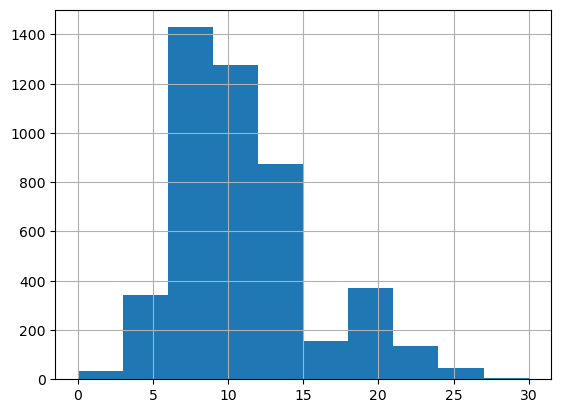

In [814]:
civil_summons_2021.yrs_of_service.hist()

In [815]:
civil_summons_2021.training_count.dtype

dtype('O')

In [816]:
# Adding back violation locations 
full_oath= pd.read_csv("data/full_2021_OATH.csv")

In [817]:
full_oath.columns.to_list()

['Ticket Number',
 'Violation Date',
 'Violation Time',
 'Issuing Agency',
 'Respondent First Name',
 'Respondent Last Name',
 'Balance Due',
 'Violation Location (Borough)',
 'Violation Location (Block No.)',
 'Violation Location (Lot No.)',
 'Violation Location (House #)',
 'Violation Location (Street Name)',
 'Violation Location (Floor)',
 'Violation Location (City)',
 'Violation Location (Zip Code)',
 'Violation Location (State Name)',
 'Respondent Address (Borough)',
 'Respondent Address (House #)',
 'Respondent Address (Street Name)',
 'Respondent Address (City)',
 'Respondent Address (Zip Code)',
 'Respondent Address (State Name)',
 'Hearing Status',
 'Hearing Result',
 'Scheduled Hearing Location',
 'Hearing Date',
 'Hearing Time',
 'Decision Location (Borough)',
 'Decision Date',
 'Total Violation Amount',
 'Violation Details',
 'Date Judgment Docketed',
 'Respondent Address or Facility Number(For FDNY and DOB Tickets)',
 'Penalty Imposed',
 'Paid Amount',
 'Additional Penalti

In [818]:
oath_rename_map = {
    'Ticket Number': 'Ticket_Number',
    'Violation Location (Borough)': 'O_violation_location_borough',
    'Violation Location (Block No.)': 'O_violation_location_block_no',
    'Violation Location (Lot No.)': 'O_violation_location_lot_no',
    'Violation Location (House #)': 'O_violation_location_house_no',
    'Violation Location (Street Name)': 'O_violation_location_street_name',
    'Violation Location (Floor)': 'O_violation_location_floor',
    'Violation Location (City)': 'O_violation_location_city',
    'Violation Location (Zip Code)': 'O_violation_location_zip_code',
    'Violation Location (State Name)': 'O_violation_location_state',

    'Respondent Address (Borough)': 'O_respondent_address_borough',
}

In [819]:
oath_cols = list(oath_rename_map.keys())

full_oath_subset = (
    full_oath[oath_cols]
    .rename(columns=oath_rename_map)
    .copy()
)


In [820]:
for df in [civil_summons_2021, full_oath_subset]:
    df['Ticket_Number'] = pd.to_numeric(df['Ticket_Number'], errors='coerce')


In [821]:
civil_summons_2021 = civil_summons_2021.merge(
    full_oath_subset,
    on='Ticket_Number',
    how='left'
)


In [822]:
civil_summons_2021.columns.to_list()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_last',
 'cs_middle',
 'pr_first',
 'pr_last',
 'pr_middle',
 'O_Violation_Date',
 'month_issued',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'aa_felony_arrest_count',
 'aa_infraction_arrest_count',
 'aa_misdemeanor_arrest_count',
 'aa_other_arrest_count',
 'aa_violation_arrest_count',
 'aa_total_arrests',
 'comme

In [823]:
# 1. Identifiers & officer names
id_cols = [
    'Ticket_Number',
    'Final_Officer_Tax_ID',
    'Officer.first.name',
    'Officer.last.name',
    'cs_first', 'cs_middle', 'cs_last',
    'pr_first', 'pr_middle', 'pr_last',
    'Officer_Total_Summonses',
    'month_issued'
]

# 2. Roster / officer demographics & status
roster_cols = [
    'roster_rank',
    'roster_command',
    'roster_race',
    'roster_gender',
]

# 3. OATH / summons-related columns (ALL O_)
o_cols = [c for c in civil_summons_2021.columns if c.startswith('O_')]

# 4. Arrest activity
arrest_cols = [
    'aa_felony_arrest_count',
    'aa_misdemeanor_arrest_count',
    'aa_violation_arrest_count',
    'aa_infraction_arrest_count',
    'aa_other_arrest_count',
    'aa_total_arrests'
]

# 5. Awards
award_cols = [
    'commendation_award_count',
    'excellent_award_count',
    'meritorious_award_count',
    'meritorious_integrity_award_count',
    'exceptional_merit_award_count',
    'total_award_count'
]

# 6. CCRB
ccrb_cols = [
    'Total.CCRB.complaints',
    'Total.substantiated.CCRB.complaints',
    'CCRB_Total_Allegations',
    'CCRB_AmericanIndian_Allegations',
    'CCRB_Asian_Allegations',
    'CCRB_Black_Allegations',
    'CCRB_Hispanic_Allegations',
    'CCRB_White_Allegations',
    'CCRB_Other_Allegations',
    'CCRB_RefusedRace_Allegations',
    'CCRB_Unknown_Allegations',
    'CCRB_fado_Abuse of Authority',
    'CCRB_fado_Discourtesy',
    'CCRB_fado_Force',
    'CCRB_fado_Offensive Language',
    'CCRB_fado_Untruthful Statement'
]

# 7. Payroll / workload
payroll_cols = [
    'Reg.hours',
    'Overtime.hours',
    'Last.active',
    'yrs_of_service'
]


In [824]:
ordered_cols = (
    id_cols +
    roster_cols +
    o_cols +
    arrest_cols +
    award_cols +
    ccrb_cols +
    payroll_cols
)

# Add any columns not explicitly listed
remaining_cols = [c for c in civil_summons_2021.columns if c not in ordered_cols]

final_cols = ordered_cols + remaining_cols


In [825]:
civil_summons_2021 = civil_summons_2021[final_cols]

In [826]:
civil_summons_2021.columns.tolist()

['Ticket_Number',
 'Final_Officer_Tax_ID',
 'Officer.first.name',
 'Officer.last.name',
 'cs_first',
 'cs_middle',
 'cs_last',
 'pr_first',
 'pr_middle',
 'pr_last',
 'Officer_Total_Summonses',
 'month_issued',
 'roster_rank',
 'roster_command',
 'roster_race',
 'roster_gender',
 'O_Violation_Date',
 'O_Violation_Time',
 'O_Issuing_Agency',
 'O_Respondent_first_name',
 'O_Respondent_last_name',
 'O_Balance_Due',
 'O_Violation_Location_Borough',
 'O_Violation_Location_City',
 'O_Violation_Location_Zip_Code',
 'O_Violation_Location_State_Name',
 'O_Respondent_Address_Borough',
 'O_Hearing_Status',
 'O_Hearing_Result',
 'O_Scheduled_Hearing_Location',
 'O_Hearing_Date',
 'O_Hearing_Time',
 'O_Decision_Location_Borough',
 'O_Decision_Date',
 'O_Total_Violation_Amount',
 'O_Violation_Details',
 'O_Date_Judgment_Docketed',
 'O_Penalty_Imposed',
 'O_Paid_Amount',
 'O_Add_Penalties_Late_Fees',
 'O_Compliance_Status',
 'O_violation_location_borough',
 'O_violation_location_block_no',
 'O_violat

In [1]:
# SAVE FINAL CIVIL_SUMMONS_2021_V1
civil_summons_2021.to_csv("data/civil_summons_2021_v1.csv")

NameError: name 'civil_summons_2021' is not defined